<center>
 <p>116 Advanced Statistics</p>
 <h1></h1>
 <h1>Lecture 05: Bayes and Bootstrap </h1>
 <p>----</p>
 <p>Prof. Jochen Braun Ph.D.</p>
 <p>Institute of Biology</p>
 <p>Otto-von-Guericke University Magdeburg</p>
 <p>----</p>
 <p>Textbook:</p>
 <p> B Efron & T Hastie (2016) Computer Age Statistical Inference, </p>
 <p> Cambridge University Press.</p>
</center>

# **Abstract:**

This lecture briefly reviews Bayesian reasoning and introduces the **Bayesian Information Criterion (BIC)** for generalized linear models.

Next it considers the problem of **false discovery rates**, which arises in modern large-scale analyses that test thousands of hypotheses concurrently. Fortunately, the issue has an elegant Bayesian solutions.

Finally, it introduces **permutational methods**, in particular **bootstrapping** for estimating standard error and confidence intervals, and **shuffling** to generate null distributions.

These important methods with be discussed further in the following lectures.




# **Overview:**


**1. Bayes Factor**

**2. Bayesian Information Criterion (BIC)**

**3. False discovery corrections**

**4. Bootstrapping for standard error and confidence**

**5. Shuffling for null distributions**




# **1. Bayes factor**

Let's refresh our Bayesian background and review **priors**, **posteriors**, and the **Bayes factor** for additional observations that can either lengthen or shorten the odds.

<br>

We start with a famous example from medical psychology and retrace the brilliant exposition by youtuber [Grant Sanderson (3blue1brown)](https://www.3blue1brown.com/lessons/better-bayes). Specifically, we consider the incidence of breast cancer in middle-aged women and the correct interpretation of screening tests.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_bayes_factor_one.png" width="600">

<br>

The indicence of breast cancer in 50 year-old women **without symptoms** is approximately 1%, or ten women in one thousand. Accordingly, the **prior odds** that any member of this population does or does not have cancer are

<br>

$$
\mathrm{Prior}\,\,\mathrm{Odds} = \frac{P(\mathrm{cancer})}{P(\mathrm{no \,\, cancer})} = \frac{1}{99}
$$



# Sensitivity and specificity of screening

The **sensitivity** and the **false negative rate** (FNR) of a screening test are defined as conditional probabilities for the **cancer-positive** subpopulation.

<br>

$$
\mathrm{Sensitivity} = P(+|\mathrm{cancer}) = \frac{9}{10}=90\%, \qquad\qquad \mathrm{FNR} = P(-|\mathrm{cancer})= \frac{1}{10}=10\%
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_bayes_factor_two.png" width="600">

<br>

In contrast, the **specificity** and the **false positive rate** (FPR) of a screening test are defined as conditional probabilities for the **cancer-negative** subpopulation.

<br>

$$
\mathrm{Specificity} = P(-|\mathrm{no\,\,cancer})=\frac{901}{990}\approx 91\%, \qquad\qquad \mathrm{FPR} = P(+|\mathrm{no\,\,cancer})=\frac{89}{990} \approx 9\%
$$

# Interpreting a screening result

So how should we interpret the result of a screening test?

<br>

The **posterior odds** are defined as the ratio of conditional probabilities, times the ratio of **prior odds**.

<br>

For a **positive** test, we find

$$
\mathrm{Posterior}\,\,\mathrm{Odds} \equiv \frac{P(\mathrm{cancer}|+)}{P(\mathrm{no}\,\,\mathrm{cancer}|+)}= \frac{P(+|\mathrm{cancer})}{P(+|\mathrm{no}\,\,\mathrm{cancer})} \cdot \frac{P(\mathrm{cancer})}{P(\mathrm{no \,\, cancer})} = \frac{90\%}{9\%} \cdot \frac{1}{99} \approx \frac{1}{10}
$$

In other words, a positive tests shortens our odds from 1/99 before the test to 1/10 after the test.

<br>

For a **negative** test, we find

$$
\mathrm{Posterior}\,\,\mathrm{Odds} \equiv \frac{P(\mathrm{cancer}|-)}{P(\mathrm{no}\,\,\mathrm{cancer}|-)} = \frac{P(-|\mathrm{cancer})}{P(-|\mathrm{no}\,\,\mathrm{cancer})} \cdot \frac{P(\mathrm{cancer})}{P(\mathrm{no \,\, cancer})} = \frac{10\%}{91\%} \cdot \frac{1}{99} \approx \frac{1}{900}
$$

so that a negative tests lengthens our odds from 1/99 before the test to 1/900 after the test.

# Probability tables

The above equates the ratios of conditional probabilities (for the **same condition**!) to the ratios of joint probabilities. Why should this be case?

<br>

As always, the comprehensive picture is provided by the probability tables for conditional and joint probabilities.

<br>

In our example, the **conditional probabilities of test results** were given:

$$\begin{array}{|cc|}
\hline
P(\mathrm{cancer}) & P(\mathrm{no \,\,cancer})   \\
0.01 & 0.99 & \\
\hline
P(\mathrm{+|cancer}) & P(+|\mathrm{no \,\,cancer})  \\
0.9 & 0.09 & \\
P(\mathrm{-|cancer}) & P(-|\mathrm{no \,\,cancer})   \\
0.1 & 0.91 & \\
\hline
\end{array}$$

<br>

Multiplying conditionals with priors (columnwise), we obtain the **joint probabilities** and the **marginal probabilities** (rowwise).

$$\begin{array}{|cc|c|}
\hline
P(\mathrm{cancer}) & P(\mathrm{no \,\,cancer})  &  \\
0.01 & 0.99 & \\
\hline
P(\mathrm{+,cancer}) & P(+,\mathrm{no \,\,cancer})  &  P(+)\\
0.009 & 0.0891 & 0.0981\\
P(\mathrm{-,cancer}) & P(-,\mathrm{no \,\,cancer})  & P(-) \\
0.001 & 0.9009 & 0.9019\\
\hline
\end{array}$$

<br>

Dividing joints by marginals (rowwise), we obtain the **conditional probabilities of cancer:**

$$\begin{array}{|cc|c|}
\hline
P(\mathrm{cancer}) & P(\mathrm{no \,\,cancer})  &  \\
0.01 & 0.99 & \\
\hline
P(\mathrm{cancer|+}) & P(\mathrm{no \,\,cancer}|+)  &  P(+)\\
0.0917 & 0.9083 & 0.0981\\
P(\mathrm{cancer|-}) & P(\mathrm{no \,\,cancer}|-)  & P(-) \\
0.0011 & 0.9989 & 0.9019\\
\hline
\end{array}$$

<br>

Now we can understand the equivalence of the ratios of conditional probabilities (same condition!) and joint probabilities:

<br>

$$
\frac{P(\mathrm{cancer}|+)\cdot P(+)}{P(\mathrm{no}\,\,\mathrm{cancer}|+)\cdot P(+)}= \frac{P(\mathrm{cancer},+)}{P(\mathrm{no}\,\,\mathrm{cancer},+)},
\qquad\qquad
\frac{P(\mathrm{cancer}|-)\cdot P(-)}{P(\mathrm{no}\,\,\mathrm{cancer}|-)\cdot P(-)}= \frac{P(\mathrm{cancer},-)}{P(\mathrm{no}\,\,\mathrm{cancer},-)}
$$

<br>

$$
\frac{P(+|\mathrm{cancer})\cdot P(\mathrm{cancer})}{P(-|\mathrm{cancer})\cdot P(\mathrm{cancer})}= \frac{P(+,\mathrm{cancer})}{P(-,\mathrm{cancer})},
\qquad\qquad
\frac{P(+|\mathrm{no\,\,cancer})\cdot P(\mathrm{no\,\,cancer})}{P(-|\mathrm{no\,\,cancer)}\cdot P(\mathrm{no\,\,cancer})}= \frac{P(+,\mathrm{no\,\,cancer})}{P(-,\mathrm{no}\,\,\mathrm{cancer})}
$$

# The twins of the physicist

Another example of Bayesian reasoning is the following story: thanks to sonograms, a physicist found out she was going to have twin boys. “What is the probability my twins will be *Identical*, rather than *Fraternal*?” she asked. The doctor answered that one-third of twin births were *Identicals*, and two-thirds *Fraternals*, so prior probabilites of 1/3 and 2/3, respectively.

<br>

In addition, we know from the sonogram that the two children will be of the same sex (boys or girls is immaterial here). The crucial background fact is that *Identical* twins are always same-sex while *Fraternals* have probability 0.5 of having the same or different sex. In other words, the conditional probabilities of same sex, given *Identical* or *Fraternal* twins, are 1 and 1/2, respectively.

<br>

Collecting this information in standard notation, we have

$$
\pi_\mathit{frat} = 2/3, \qquad \pi_\mathit{ident} = 1/3
$$

$$
\mathrm{Pr}(\mathrm{samesex}|\mathrm{frat}) = 1/2, \qquad  \mathrm{Pr}(\mathrm{samesex}|\mathrm{ident}) = 1
$$

<br>

Combining this into Bayes fractions, we have

$$
\frac{\mathrm{Pr}(\mathrm{frat}|\mathrm{samesex})}{\mathrm{Pr}(\mathrm{ident}|\mathrm{samesex})} = \frac{\mathrm{Pr}(\mathrm{samesex}|\mathrm{frat})}{\mathrm{Pr}(\mathrm{samesex}|\mathrm{ident})} \cdot \frac{\pi_\mathit{frat}}{\pi_\mathit{ident}} = \frac{1/2}{1}\cdot \frac{2/3}{1/3} = \frac{1}{1}
$$

<br>

In other words, the prior odds **against** *Identical* twins were levelled out by the same-sex sonogram, which **favours** *Identical* twins.

# Probability of aliens (optional)

Let $p$ be the prior probability that a star system is inhabited by a sentient species. If we survey $N$ star systems (including our own), the binomial probability of observing exactly $n$ inhabited systems is

$$
P_n(p,N) = \binom{N}{n}\, p^n \, (1-p)^{N-n}
$$

The conditional probability of two or more inhabited system, given that there already exists one such system (our own) is

$$
P_\mathit{alien}(p,N) = \frac{1 - P_0(p,N) - P_1(p,N)}{1 - P_0(p,N)}
$$

<br>

A conservative estimate for the prior probability is $p=\frac{1}{N}$, since our own system exists. Accordingly, we can estimate the probability of aliens, as a function of $N$, as follows

$$
P_\mathit{alien}(N) = \frac{1 - P_0(1/N,N) - P_1(1/N,N)}{1 - P_0(1/N,N)}
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_finding_aliens.png" width="600">

<br>

This calculation shows that the probability of finding aliens asymptotes at 42% as the number of surveyed solar systems increases.  Douglas Adams knew this all along.

<br>

**Cautionary note:** due to our limited knowledge, we assign the same prior probability to microbial life, multicellular macroscopic life, and sentient life. Surely these will turn out to be vastly different!

# **1. Bayesian Information Criterion (BIC)**

To motivate this approach, let's for one moment return to our statistical utopia where everything is known or calculable.

<br>

Consider an independent normal sample

$$
{\bf x} = (x_1, x_2, \ldots , x_n), \qquad\qquad x_i\sim \mathscr{N}(\mu,1)
$$

and the problem of distingushing between two hypotheses or 'models'.

$$
\mathscr{M}_0: \mu=0, \qquad\qquad \mathscr{M}_1: \mu\neq 0
$$

<br>

As we inhabit a utopian scenario, we know the prior probabilities of both models

$$
\mathrm{Pr}\left(\mathscr{M}_0\right) = \pi_0, \qquad\qquad \mathrm{Pr}\left(\mathscr{M}_1\right) =\pi_1 = 1 - \pi_0
$$

as well as the conditional prior densities of $\mu$ under both models

$$
g_0(\mu) = g\left(\mu | \mathscr{M}_0 \right), \qquad\qquad g_1(\mu) = g\left(\mu | \mathscr{M}_1 \right)
$$

If $f_\mu({\bf x})$ is the density of $\bf x$ given $\mu$, the marginal distributions of ${\bf x}$ follow as

$$
f_0({\bf x}) = \int f_\mu({\bf x}) \, g_0({\bf \mu}) \, d{\bf \mu},\qquad\qquad f_1({\bf x}) = \int f_\mu({\bf x}) \, g_1({\bf \mu}) \, d{\bf \mu}
$$

<br>

From Bayes' theorem, we can now obtain the posterior probability ratio of models, given our observations ${\bf x}$,

$$
\frac{\pi_1({\bf x})}{\pi_0({\bf x})} \quad= \quad \frac{f_1({\bf x})}{f_0({\bf x})} \cdot \frac{\pi_1}{\pi_0}
$$

<br>

as the product of the Bayes factor $B({\bf x}) = \frac{f_1({\bf x})}{f_0({\bf x})}$ and the prior probability ratio $\frac{\pi_1}{\pi_0}$






# Bayesian information criterion (BIC)

The BIC is a heuristic that compares quality of model fit and model complexity.  Specifically

<br>

$$
\mathrm{BIC} = -2 \log( \mathscr{\hat L}) + p \log (n)
$$

<br>

where $\mathscr{\hat L} = f_1({\bf x})$ is the likelhood of the observed data ${\bf x}$ under model $\mathscr{M}_1$, $p$ is the number of model parameters, and $n$ is the number of data points.

<br>

A **lower BIC** indicates a **better model**.

<br>


# BIC for normally distributed observations

For normally distributed observation errors, the likelihood of observations is

$$
f_1({\bf x}) = \frac{1}{\left(2\pi \, \left\langle\sigma_e^2\right\rangle\right)^{n/2}} \,\, \exp\left(-\frac{1}{2\left\langle\sigma_e^2\right\rangle}\sum_{i=1}^n \left(x_i-\mu\right)^2\right)
$$

where error variance is estimated from the **residual sum of squares, RSS**

$$
\left\langle\sigma_e^2\right\rangle = \frac{1}{n} \sum_{i=1}^n(x_i - \mu)^2
$$

so that the log likelihood becomes

$$\begin{eqnarray}
\log f_1({\bf x}) &=& -\frac{n}{2} \log (2\pi) - \frac{n}{2} \log  \left\langle\sigma_e^2\right\rangle - \frac{1}{2\left\langle\sigma_e^2\right\rangle} \sum_{i=1}^{n} (x_i - \mu)^2 =
\\
&=& -\frac{n}{2} \log (2\pi) - \frac{n}{2} \log  \left\langle\sigma_e^2\right\rangle - \frac{n }{2}
\end{eqnarray}$$

<br>

and the BIC becomes

$$\begin{eqnarray}
BIC &=& - 2 \log f_1({\bf x}) + p \log n =
\\
\\
&=& n \log(2\pi)  + n \log \left\langle\sigma_e^2\right\rangle + n + p \log n \propto
\\
\\
&\propto&  n \log \left\langle\sigma_e^2\right\rangle +  p \log n
\end{eqnarray}$$

<br>

The constant terms $n \log(2\pi) + n$ can be ignored for purposes of model comparison.

<br>


In [ ]:
from inspect import signature
# @title BIC with normally distributed observations {"vertical-output":true,"display-mode":"form"}
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from scipy.stats import poisson
from scipy.stats import norm
from scipy.stats import binom
from scipy.optimize import curve_fit


def plot_BIC_with_normal_data(n = 20, sigma_e=2):

    # Regression data
    x = np.arange(1, n).reshape(-1, 1)
    y = 0.2 * (x - 5)**2 + 2 * x + np.random.normal(0, sigma_e, size=x.shape)

    n = len(x)

    # --- Model M1: Linear (intercept + x) ---
    X1 = np.hstack((np.ones_like(x), x))  # Design matrix with intercept
    b1 = np.linalg.lstsq(X1, y, rcond=None)[0]  # Least squares fit

    y1 = X1 @ b1  # Prediction
    varerr1 = np.mean((y - y1)**2)

    p1 = 3  # 2 model params + sigma
    BIC1 = n * np.log(varerr1) + p1 * np.log(n)

    # --- Model M2: Quadratic (intercept + x + x^2) ---
    X2 = np.hstack((np.ones_like(x), x, x**2))  # Add x^2 term
    b2 = np.linalg.lstsq(X2, y, rcond=None)[0]

    y2 = X2 @ b2  # Prediction
    varerr2 = np.mean((y - y2)**2)

    p2 = 4  # Same number of parameters
    BIC2 = n * np.log(varerr2) + p2 * np.log(n)

    # Bayes factor model 2 versus model 1
    BF = np.exp(BIC1 - BIC2)

    BFalt = varerr2**n / varerr1**n * n**p1 / n**p2

    print(" Bayes factors:", BF, BFalt)

    # --- Plot ---
    xx = np.linspace(0, n, 100).reshape(-1, 1)
    yy1 = b1[0] + b1[1]*xx
    yy2 = b2[0] + b2[1]*xx + b2[2]*xx**2

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, 'ko', label='Data')
    plt.plot(xx, yy1, 'b-', linewidth=2, label='Linear model')
    plt.plot(xx, yy2, 'r-', linewidth=2, label='Quadratic model')
    plt.gca().set_aspect(4/n, adjustable='box')
    plt.legend()
    plt.title(f'BIC Model 1: {BIC1:.2f} BIC Model 2: {BIC2:.2f}')
    plt.xlabel('x')
    plt.ylabel('y')

    plt.tight_layout()
    plt.show()

# Creating sliders for concentrations and charge
interact(plot_BIC_with_normal_data, n = (10,100,10), sigma_e = (1, 10, 1 )  )


interactive(children=(IntSlider(value=20, description='n', min=10, step=10), IntSlider(value=2, description='s…

<function __main__.plot_BIC_with_normal_data(n=20, sigma_e=2)>

# Bayes factor and BIC

The BIC lets us compare models in terms of a Bayes factor, if we assume

$$
P(\mathscr{M}_1|{\bf x}) = e^{-BIC(\mathscr{M}_1)}, \qquad\qquad P(\mathscr{M}_0|{\bf x})= e^{-BIC(\mathscr{M}_0)}
$$

<br>

$$
\log B_\mathrm{BIC}({\bf x}) = \mathrm{BIC}(\mathscr{M}_0) - \mathrm{BIC}(\mathscr{M}_1) = - 2 \log\frac{f_0({\bf x})}{f_1({\bf x})} + (p_0 - p_1) \log(n)
$$

$$
B_\mathrm{BIC}({\bf x}) =\frac{P(\mathscr{M}_1|{\bf x})}{P(\mathscr{M}_0|{\bf x})}= \exp\left[ \mathrm{BIC}(\mathscr{M}_0) - \mathrm{BIC}(\mathscr{M}_1)\right] = \left[\frac{f_1({\bf x})}{f_0({\bf x})}\right]^2 \cdot \frac{n^{p_0}}{n^{p_1}}
$$

<br>

that describes how our observations $\bf x$ change the odds in favour of one model or another.

<br>

In the coded toy example above, the BIC of Model 1 is $\sim 80$, whereas that of Model 2 is $\sim 30$, so that the odds change by a factor of $10^{18}$ in favour of Model 2:

$$
B_\mathrm{BIC} \approx e^{-30+80} \approx 10^{18}
$$

# BIC with Poisson distributed observations

For Poisson distributed observations $\bf y$ with expectation $\boldsymbol\mu=\langle {\bf y}\rangle$, the natural parameter is $\boldsymbol\lambda = \log \boldsymbol\mu$, which we fit as

$$
\boldsymbol\lambda (\boldsymbol \alpha) = \log \boldsymbol\mu(\boldsymbol \alpha) = {\bf X} \cdot \boldsymbol \alpha
$$

<br>

The Poisson distribution is

$$
f_{\mu}(y) = \frac{\mu^y \, e^{-\mu}}{y!}, \qquad\qquad \log f_{\mu}(y) = y\log \mu - \mu - \mathit{const} = y\lambda - e^\lambda - \mathit{const}
$$

so that the (parameter-dependent part of the) log likelihood of observations given model predictions $\boldsymbol\mu(\boldsymbol \alpha)$ is

$$
\log f_{\boldsymbol\mu}({\bf y}) = \sum_i \log f_{\mu_i}(y_i) = \sum_i \left[ y_i \log \mu_i - \mu_i\right]= \sum_i \left[ y_i \lambda_i - e^{\lambda_i}\right]
$$

The BIC then becomes

$$
BIC_\mathit{Poisson} = - 2 \log f_{\boldsymbol\mu}({\bf y})+ p \log (n)
$$

where $p$ is the number of parameters in $\alpha$ plus 1 (for error variance) and $n$ is the number of observations.

<br>

The Bayes factor between two models $\mathscr{M}_1$ and $\mathscr{M}_2$ is

$$
\frac{P(\mathscr{M}_1|{\bf x})}{P(\mathscr{M}_2|{\bf x})}= \exp\left[ \mathrm{BIC}(\mathscr{M}_2) - \mathrm{BIC}(\mathscr{M}_1)\right] = \left[\frac{f_1({\bf x})}{f_2({\bf x})}\right]^2 \cdot \frac{n^{p_2}}{n^{p_1}}
$$

and the logarithm is

$$\begin{eqnarray}
\log\left[\frac{P(\mathscr{M}_1|{\bf x})}{P(\mathscr{M}_2|{\bf x})}\right]&=&  2 \log \left[\frac{f_1({\bf x})}{f_2({\bf x})} \right] + (p_2-p_1) \log(n) =
\\
\\
&=&
2 \sum_i  y_i \left[\lambda_i^{(1)}-\lambda_i^{(2)}\right] - 2\sum_i \left[ e^{\lambda_i^{(1)}}- e^{\lambda_i^{(2)}}\right] + (p_2-p_1) \log(n)
\end{eqnarray}$$


-714.7021431317858 -997.8471338196173


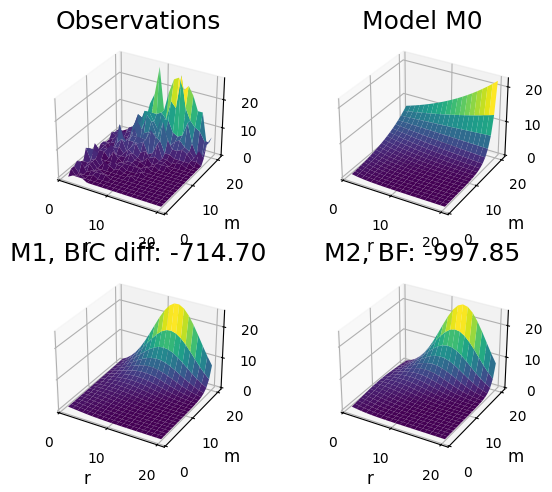

In [ ]:
# @title BIC example for Poisson regression {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import statsmodels.api as sm

# define data support
Nr = 20;
Nm = 20;

rrange = np.arange(1,Nr+1)
mrange = np.arange(Nm,0,-1)

rarray = np.tile( rrange, (Nr, 1) )
marray = np.tile( mrange, (Nm, 1) ).T

# define bivariate distribution of natural parameter

alpha_true = np.array([-0.34783406,  0.14192231, -0.0223069,   0.04640992, -0.00861051]);
alpha_true = alpha_true.reshape(-1,1)

# flatten arrays

r = rarray.reshape(-1,1)
m = marray.reshape(-1,1)

# design matrix

X_true = np.hstack((r, m, r**2, r*m, m**2))

# generate observations
lambda_true = X_true @ alpha_true
mu_true  = np.exp(lambda_true)

y = np.random.poisson(mu_true)

yarray = y.reshape(Nm,Nr)


# Design matrix of model 2

X_M2 = np.hstack((r, m, r**2, r*m, m**2))

# Fit GLM with Poisson distribution, using STATSMODELS
model = sm.GLM(y, X_M2, family=sm.families.Poisson(sm.families.links.Log()))
results = model.fit()

alpha_M2 = results.params

# Predicted observations
lambda_M2 = X_M2 @ alpha_M2
mu_M2  = np.exp(lambda_M2)

y_M2 = mu_M2.reshape(Nm,Nr)
y_M2_array = y_M2.reshape(Nm,Nr)

# Design matrix of model 1

X_M1 = np.hstack((r, m, r**2, r*m))

# Fit GLM with Poisson distribution, using STATSMODELS
model = sm.GLM(y, X_M1, family=sm.families.Poisson(sm.families.links.Log()))
results = model.fit()

alpha_M1 = results.params

# Predicted observations
lambda_M1 = X_M1 @ alpha_M1
mu_M1  = np.exp(lambda_M1)

y_M1 = mu_M1.reshape(Nm,Nr)

y_M1_array = y_M1.reshape(Nm,Nr)

# Design matrix of model 0

X_M0 = np.hstack((r, m, r*m))

# Fit GLM with Poisson distribution, using STATSMODELS
model = sm.GLM(y, X_M0, family=sm.families.Poisson(sm.families.links.Log()))
results = model.fit()

alpha_M0 = results.params

# Predicted observations
lambda_M0 = X_M0 @ alpha_M0
mu_M0  = np.exp(lambda_M0)

y_M0 = mu_M0.reshape(Nm,Nr)

y_M0_array = y_M0.reshape(Nm,Nr)

# Define negative log-likelihood for Poisson distribution
def neg_log_likelihood(alpha, X, y):
    natparam = X @ alpha
    log_likelihood = y * natparam - np.exp(natparam)
    return -np.sum(log_likelihood)

# Define BIC for Poisson distribution
def bayesian_information_content(alpha, X, y):
    natparam = X @ alpha
    log_likelihood = y * natparam - np.exp(natparam)

    BIC = -2 * np.sum(log_likelihood) + len(alpha) * np.log( len(y) )

    return BIC

# compute BICs

BIC_M0 = bayesian_information_content(alpha_M0, X_M0, y) / len(y)
BIC_M1 = bayesian_information_content(alpha_M1, X_M1, y) / len(y)
BIC_M2 = bayesian_information_content(alpha_M2, X_M2, y) / len(y)

Delta_BIC_10 = BIC_M0 - BIC_M1
Delta_BIC_21 = BIC_M1 - BIC_M2

print( Delta_BIC_10, Delta_BIC_21 )

# Visualize results
fig = plt.figure()

# Plot 1: Original counts
ax0 = fig.add_subplot(221, projection='3d')

ax0.plot_surface(rarray, marray, yarray, cmap='viridis')  # You can change colormap

ax0.set_xlabel('r', fontsize=12)
ax0.set_ylabel('m', fontsize=12)
ax0.set_title('Observations', fontsize=18)

# Plot 2: Model 0
ax1 = fig.add_subplot(222, projection='3d')

ax1.plot_surface(rarray, marray, y_M0_array, cmap='viridis')  # You can change colormap

ax1.set_xlabel('r', fontsize=12)
ax1.set_ylabel('m', fontsize=12)
ax1.set_title(f'Model M0', fontsize=18 )

# Plot 2: Model 1
ax1 = fig.add_subplot(223, projection='3d')

ax1.plot_surface(rarray, marray, y_M1_array, cmap='viridis')  # You can change colormap

ax1.set_xlabel('r', fontsize=12)
ax1.set_ylabel('m', fontsize=12)
ax1.set_title(f'M1, BIC diff: {Delta_BIC_10:.2f}', fontsize=18 )

# Plot 2: Model 2
ax1 = fig.add_subplot(224, projection='3d')

ax1.plot_surface(rarray, marray, y_M2_array, cmap='viridis')  # You can change colormap

ax1.set_xlabel('r', fontsize=12)
ax1.set_ylabel('m', fontsize=12)
ax1.set_title(f'M2, BF: {Delta_BIC_21:.2f}', fontsize=18 )

plt.tight_layout()
plt.show()


# **3. False discovery corrections**

Many modern techniques with large-scale testing pose the statistical problem of false (accidental) positives. Performing 100 separate tests at significance level $\alpha=0.05$, will **falsely discover** approximately five "significant" purely by chance.

Efron & Hastie (Chapter 15) present an example from a **prostate cancer** study with microarrays, involving 102 men, 52 prostate cancer patients and 50 normal controls. For each man, expression levels were measured for 6033 genes, yielding a $6033 \times 102$ matrix of observations $x_{ij}$, with $i$ indexing genes and $j$ indexing men.

For each gene, a two-sample statistic compared expression levels patient and control groups. Under the null hypothesis H0 that expression levels come from the same normal distribution, the $t_i$ for gene $i$ will follow a standard Student t distribution with $100$ degrees of freedom, $t_{100}$. Transformation with the CDF of $t_{100}$ and the inverse normal PDF produces standard normally distributed observations, $z_i$, under the null hypothesis:

$$
z_i = \Phi^{-1}\left[F_{100}(t_i) \right]
$$

The illustration below compares the observed distribution (histogram) with the null hypothesis (red curve), a standard normal distribution, scaled to counts:

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_prostate_cancer_genes.png" width="600">

<br>

**So the question is, are some genes significantly over- or under-expressed?**


# Bonferroni correction

The classical Bonferroni correction lowers the threshold of significance from $\alpha$ for an individual test to $\alpha/N$ for $N$ simultaneous tests. In other words, the null hypothesis is rejected only when the $p$-value of some test is $p<\alpha/N$.

<br>

In the case of the prostate cancer study, with $N=6033$, the Bonferroni-corrected threshold for significance would be

$$
\alpha_\mathit{corr} = \frac{\alpha}{N} = \frac{0.05}{6033} = 8.3\times 10^{-6}
$$

This standard of evidence is quite stringent and only four genes in the cancer study pass this test.


# Benjamini-Hochberg correction

The current standard is more liberal and was proposed by [Benjamini & Hochberg (2019)](https://academic.oup.com/jrsssb/article/57/1/289/7035855?login=false), whose paper has been cited 115,940 times to date!

<br>

If the true proportion of non-null hypotheses is $\frac{N_1}{N_0+N_1}$ and our statistical decision rule $\mathscr{D}$ yields a proportion of $\frac{R}{R+N}$, the the **false-discovery rate (FDR)** would be

$$
\mathrm{FDR}(\mathscr{D}) = \frac{a}{R}
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_FDR_definition.png" width="500">

<br>

We are seeking a decision rule that keeps the FDR below some chosen level, $q$

<br>

$$
\mathrm{FDR}(\mathscr{D}) \leq q
$$

<br>

The procedure for doing this is the order the observed p-values from the largest to the smallest, and to reject the null hypothesis for all values with

<br>

$$
p_i \leq \frac{i}{N} \, q
$$

<br>

with a conventional choice of $q=0.1$.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_benjamini_hochberg.png" width="500">


<br>

In the cancer study, FDR rejects the null-hypothesis for 28 genes in the right tail of the distribution (over-expression).



# Bayesian motivation for FDR

Benjamini & Hochberg derived their method in a different way (Martingale theory), but it can be easily motivated in a Bayesian way.

<br>

Assuming that our observations (gene expression levels) reflect a **mixed** population with a large fraction $\pi_0\approx 1$ of expression levels distributed normally about mean zero

$$
f_0(z) \sim \mathscr{N}(0,1)
$$

but a small fraction $\pi_1= 1 - \pi_0$ distributed about some larger mean $\mu_1>0$

$$
f_1(z) \sim \mathscr{N}(\mu_1,1)
$$

the mixed density will be

$$
f_\mathit{mix}(z) = \pi_0 f_0(z) + \pi_1 f_1(z)
$$

and the survivor fraction will be

$$
S_\mathit{mix}(z_\theta) = \int_{z_\theta}^\infty f_\mathit{mix}(z) \, dz = \pi_0 S_0(z_\theta) + \pi_1 S_1(z_\theta)
$$

<br>

If we rank our $N$ observed $z_i$ values, where $i$ is the rank **from the largest** value, the false discovery rate at level of $z_i$ is defined as

<br>

$$
\mathrm{FDR} = \frac{\pi_0 \, S_0(z_i)}{S_\mathit{mix}(z_i)}, \qquad\qquad S_\mathit{mix}(z_i) \approx \frac{i}{N}
$$

<br>

where $S_\mathit{mix}(z_i)$ is well approximated by $\frac{i}{N}$ for large $N$.

<br>

In other words, if we can tolerate a false discovery rate of $q$, we need to restrict the probability $p_i$ of spurious discovery to

<br>

$$
p_i = \pi_0 S_0)z_i) \quad \leq \quad S_\mathit{mix}(z_i) \cdot q \approx \frac{i}{N} \cdot q
$$

# Local false discovery rates

Let's apply this Bayesian viewpoint to the tail of our distributions and define a **local false discovery rate** for a small region $\mathscr{Z}_0$ centered on $z_0$

<br>

$$
\mathrm{fdr}(\mathscr{Z}_0) = \mathrm{Pr}\left(\mathrm{null} | z_i \in \mathscr{Z}_0 \right), \qquad\qquad \mathscr{Z}_0 = \left[z_0-\frac{d}{2} , z_0 + \frac{d}{2} \right]
$$

<br>

Comparing the observed number  of $z_i$ in this region, $N(\mathscr{Z}_0)$, to the number expected from a standard normal distribution, $N_0 (\mathscr{Z}_0)$, we can estimate

<br>

$$
\mathrm{fdr}(\mathscr{Z}_0) = \frac{N_0 (\mathscr{Z}_0)}{N(\mathscr{Z}_0) } \approx \frac{N \pi f_0(z_0) d}{N(\mathscr{Z}_0)}
$$

<br>

Typically, these estimates are computed for different window centers $z_0$ an then smoothed by some polynomial fit. Once again, this approach works only when the number of hypothesis tests is quite large.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_local_fdr.png" width="500">


<br>

In our cancer study, 27 genes in the right tail and 25 genes in the left tail passed the threshold $fdr\leq q$ (the conventional threshold of "interesting" or worthy of further study), in the sense that $z_i \geq 3.34$ or $z_i\leq -3.40$.






# **4. Bootstrapping for standard error and confidence**

Often we have a (smallish) set of observations ${\bf x} = (x_1, x_2, \ldots , x_n)$ from some unknown probability distribution $F$

$$
x_i \sim F\qquad\qquad i = 1, 2, \ldots, n
$$

and have computed a (real-valued) statistic $\theta$ with some algorithm or procedure $s({\bf x})$

$$
\theta = s({\bf x})
$$

Note that this situation is quite general: the samples $x_i$ can be univariate, bivariate, multivariate, the distribution is not restricted to any parametric family, and the algorithm $s({\bf x})$ can be anything.

<br>

So is there any way to estimate a standard error for $\hat\theta$, in other words, estimate the variance we would expect if (counterfactually) we could repeat our experiment many times?

<br>

Suprisingly, there is a simple (albeit computationally intensive) familiy of solutions for this problem, which are known collectively as **bootstrapping**.



# Jackknife estimate

This is a versatile and handy tool for many situations, much like a pocket knife or jackknife.

<br>

Let's remove one observation, $x_i$, from our sample ${\bf x}$, and denote with ${\bf x}_{(i)}$ the smaller sample that results  

$$
{\bf x}_{(i)} = (x_1, \ldots , x_{i-1}, x_{i+1}, \ldots , x_n)
$$

and with $\theta_{(i)}$ the corresponding value of our statistic

$$
\theta_{(i)} = s({\bf x}_{(i)})
$$

<br>

The Jackknife estimate for standard error is

$$
\mathrm{se}_\mathit{jack} = \left[ \frac{n-1}{n} \sum_{i=1}^n \left(\theta_{(i)}-\theta_{(\cdot)} \right)^2 \right]^{-1/2}, \qquad\qquad \theta_{(\cdot)} = \frac{1}{n} \sum_{i=1}^n \theta_{(i)}
$$

<br>

As a transparent example, consider the case when $\theta=s(x)$ is simply the mean of real-valued $x_i$

$$
\theta = \bar x = \frac{1}{n} \sum_i x_i, \qquad\qquad \theta_{(i)}= \frac{n \bar x - x_i}{n-1}
$$

In this case, the average and the deviation from the average are

$$
\theta_{(\cdot)} = \frac{1}{n}\sum_i \theta_{(i)} = \frac{n \bar x}{n-1}- \frac{\bar x}{n-1} = \bar x, \qquad\qquad \theta_{(i)}-\theta_{(\cdot)}=\frac{n \bar x - x_i}{n-1} - \frac{\bar x(n-1)}{n-1} = \frac{\bar x - x_i}{n-1}
$$

and the Jackknife estimate

$$
\mathrm{se}_\mathit{jack} = \left[ \frac{n-1}{n} \sum_{i=1}^n \left(\theta_{(i)}-\theta_{(\cdot)} \right)^2 \right]^{-1/2} = \left[ \frac{1}{n(n-1)} \sum_{i=1}^n \left(x_i - \bar x \right)^2 \right]^{-1/2}
$$

equals the classical standard error for normally distributed samples.

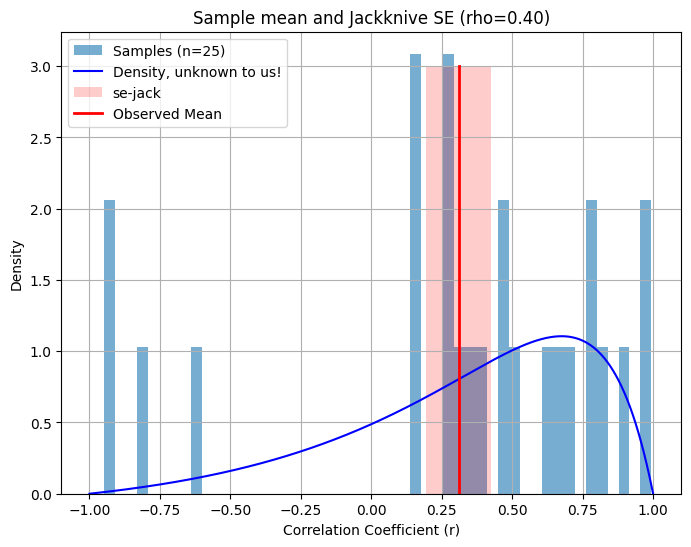

In [ ]:
# @title Jackknife example, sampling from Fisher's correlation density {"vertical-output":true,"display-mode":"form"}

import numpy as np
from scipy.special import gamma, beta, hyp2f1
import matplotlib.pyplot as plt
from scipy.stats import norm

def jackknife_mean_error(data):
    """
    Compute the Jackknife standard error estimate for the sample mean.

    Parameters:
    data : array-like, input sample data

    Returns:
    se_jack : float, Jackknife standard error estimate
    mean : float, sample mean
    jack_means : array, leave-one-out means
    """
    # Convert input to numpy array
    data = np.array(data)
    n = len(data)

    if n < 2:
        raise ValueError("Sample size must be at least 2 for Jackknife estimation.")

    # Compute original sample mean
    mean = np.mean(data)

    # Compute leave-one-out means
    jack_means = np.zeros(n)
    for i in range(n):
        # Mean of data excluding i-th observation
        jack_means[i] = np.mean(np.delete(data, i))

    # Compute Jackknife standard error
    se_jack = np.sqrt((n - 1) / n * np.sum((jack_means - np.mean(jack_means))**2))

    return se_jack, mean, jack_means

def correlation_density_rho(r, rho, n):
    """
    Compute the probability density function of the Pearson correlation coefficient r
    for a sample size n and population correlation rho, as derived by R.A. Fisher.

    Parameters:
    r : float or array-like, correlation coefficient(s) in [-1, 1]
    rho : float, population correlation coefficient in (-1, 1)
    n : int, sample size (n >= 3)

    Returns:
    density : float or array-like, the density f(r | rho, n) at the given r
    """
    if n < 3:
        raise ValueError("Sample size n must be at least 3.")
    if not -1 < rho < 1:
        raise ValueError("Population correlation rho must be in (-1, 1).")

    # Ensure r is in [-1, 1]
    r = np.clip(r, -1, 1)

    # Constants
    term1 = (n - 2) * gamma(n - 1) / (np.sqrt(2 * np.pi) * gamma(n - 0.5))
    term2 = (1 - rho**2)**((n - 1) / 2)
    term3 = (1 - r**2)**((n - 4) / 2)
    term4 = (1 - rho * r)**(3/2 - n)

    # Hypergeometric function _2F_1(1/2, 1/2; (2n-3)/2; (rho*r + 1)/2)
    hypergeom = hyp2f1(0.5, 0.5, (2 * n - 3) / 2, (rho * r + 1) / 2)

    # Combine terms
    density = term1 * term2 * term3 * term4 * hypergeom

    # Handle numerical stability (avoid NaNs or negative densities)
    density = np.where(np.isfinite(density), density, 0)

    return density

def sample_correlated_pairs( x, y, num_samples=1):
    """
    Generate synthetic observations, returned in r_sample
    For this purpose, sample the provided list of pairs with replacement
    The correlation coefficient of bootstrapped lists of pairs
    provides a synthetic observation

    Don't be confused that bootstrapping is used twice:
    Once for sample generation (in this function)
    Again to evaluate the SE of the sample averate (Jackknife, Bootstrap)
    """

    if n < 3:
        raise ValueError("Sample size n must be at least 3.")
    if not -1 < rho < 1:
        raise ValueError("Population correlation rho must be in (-1, 1).")


    r_unclean = np.zeros(num_samples)

    for i in range(num_samples):

        # Randomly sample indices with replacement
        sampled_indices = np.random.choice(n, size=n, replace=True)

        # Extract sampled elements
        sampled_x = x[sampled_indices]
        sampled_y = y[sampled_indices]

        r_unclean[i] = np.corrcoef(sampled_x, sampled_y)[0, 1]

    r_sample = r_unclean[~np.isnan(r_unclean)]

    return r_sample

def generate_correlated_pairs(n, rho, mu_x=0, mu_y=0, sigma_x=1, sigma_y=1):
    """
    Generate n pairs (x_i, y_i) from a bivariate normal distribution with correlation rho.

    Parameters:
    n : int, number of sample pairs
    rho : float, desired correlation coefficient in (-1, 1)
    mu_x : float, mean of X (default: 0)
    mu_y : float, mean of Y (default: 0)
    sigma_x : float, standard deviation of X (default: 1)
    sigma_y : float, standard deviation of Y (default: 1)
    random_seed : int, seed for reproducibility (default: None)

    Returns:
    x : array, x-coordinates of the sample pairs
    y : array, y-coordinates of the sample pairs
    sample_rho : float, observed correlation of the generated pairs
    """
    if n < 1:
        raise ValueError("Sample size n must be at least 1.")
    if not -1 < rho < 1:
        raise ValueError("Correlation rho must be in (-1, 1).")
    if sigma_x <= 0 or sigma_y <= 0:
        raise ValueError("Standard deviations must be positive.")

    # Define covariance matrix
    cov_matrix = np.array([[sigma_x**2, rho * sigma_x * sigma_y],
                           [rho * sigma_x * sigma_y, sigma_y**2]])

    # Cholesky decomposition: cov_matrix = L @ L.T
    L = np.linalg.cholesky(cov_matrix)

    # repeat in order to get close to desired rho
    Ntry = 1000

    x = np.empty((Ntry,n))
    y = np.empty((Ntry,n))
    sample_rho = np.empty(Ntry)

    for i in range(Ntry):

        # Generate independent standard normal variables
        Z = np.random.normal(0, 1, size=(n, 2))

        # Transform to correlated variables: W = L @ Z.T
        W = (L @ Z.T).T  # Shape: (n, 2)

        # Add means
        x[i,:] = mu_x + W[:, 0]
        y[i,:] = mu_y + W[:, 1]

        # Compute observed correlation
        sample_rho[i] = np.corrcoef(x[i,:], y[i,:])[0, 1]

    # select sample nearest to desired rho
    rho_deviation = np.abs(sample_rho - rho)
    ixclose = np.where( rho_deviation == np.min(rho_deviation))[0]

    ix = ixclose[0]

    return x[ix,:], y[ix,:], sample_rho[ix]

# Example usage: Draw samples and plot histogram for n=5, rho=0.5
if __name__ == "__main__":

    # Parameters
    n = 6
    rho = 0.4
    num_samples = 25

    # generate list of correlated value pairs, with sample_rho near rho
    (x, y, sample_rho) = generate_correlated_pairs(n, rho)

    # Draw samples
    samples = sample_correlated_pairs(x, y, num_samples)

    # observed sample mean
    sample_mean = np.mean(samples)

    (se_jack, mean, jack_means) = jackknife_mean_error( samples );

    ymax = 3

    xbox = sample_mean + se_jack * np.array([-1, 1, 1, -1]);
    ybox = ymax * np.array([0, 0, 1, 1]);

    # Compute theoretical density for comparison
    r_values = np.linspace(-1, 1, 1000)
    density = correlation_density_rho(r_values, sample_rho, n)

    # Plot histogram of samples and theoretical density
    plt.figure(figsize=(8, 6))
    plt.hist(samples, bins=50, density=True, alpha=0.6, label=f'Samples (n={num_samples})')
    plt.plot(r_values, density, 'b-', label='Density, unknown to us!')
    plt.fill(xbox, ybox, 'r', alpha=0.2, label='se-jack')
    plt.plot([sample_mean,sample_mean], [0,ymax], 'r-', linewidth=2, label='Observed Mean')
    plt.title(f"Sample mean and Jackknive SE (rho={sample_rho:.2f})")
    plt.xlabel('Correlation Coefficient (r)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()


# Nonparametric bootstrap

We stay with our general problem of a smallish set of observations ${\bf x} = (x_1, x_2, \ldots , x_n)$ from some unknown probability distribution $F$

$$
x_i \sim F\qquad\qquad i = 1, 2, \ldots, n
$$

for which we have computed a (real-valued) statistic $\theta$ with some algorithm or procedure $s({\bf x})$

$$
\theta = s({\bf x})
$$

<br>

Bootstrapping estimates the unknown distribution $F$ by generating from our on original sample many **bootstrap samples**

$$
{\bf x}^* = (x_1^*, x_2^*, \ldots , x_n^*)
$$

by simply drawing each $x_i^*$ randomly (with equal probability and with replacement) from $(x_1, x_2, \ldots , x_n)$. From each bootstrap sample, we obtain a bootstrap replicate for our statistic $\theta$

$$
\theta_{b} = s\left({\bf x}^{*}_{b} \right), \qquad\qquad b = 1, 2, \ldots , B
$$

where $b$ indexes the $B$ repetitions of our boostrap. The boostrap standard error is then

$$
\mathrm{se}_\mathit{boot} = \left[ \frac{1}{B-1} \sum_{b=1}^B \left(\theta_{b}-\theta_{(\cdot)} \right)^2 \right]^{-1/2}, \qquad\qquad \theta_{(\cdot)} = \frac{1}{B} \sum_{b=1}^B \theta_{b}
$$


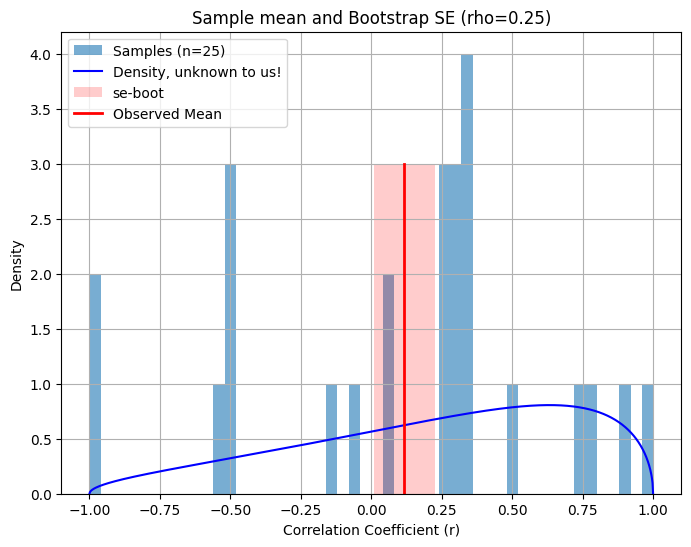

In [ ]:
# @title Bootstrap example, again with Fisher's correlation density {"vertical-output":true,"display-mode":"form"}

import numpy as np
from scipy.special import gamma, beta, hyp2f1

def bootstrap_mean_error(data, num_bootstrap=1000):
    """
    Compute the bootstrap standard error estimate for the sample mean.

    Parameters:
    data : array-like, input sample data
    num_bootstrap : int, number of bootstrap samples (default: 1000)
    random_seed : int, seed for reproducibility (default: None)

    Returns:
    se_boot : float, bootstrap standard error estimate
    mean : float, sample mean
    boot_means : array, means of bootstrap samples
    """
    # Convert input to numpy array
    data = np.array(data)
    n = len(data)

    if n < 2:
        raise ValueError("Sample size must be at least 2 for bootstrap estimation.")
    if num_bootstrap < 1:
        raise ValueError("Number of bootstrap samples must be at least 1.")

    # Compute original sample mean
    mean = np.mean(data)

    # Generate bootstrap samples and compute their means
    boot_means = np.zeros(num_bootstrap)
    for b in range(num_bootstrap):
        # Sample with replacement
        boot_sample = np.random.choice(data, size=n, replace=True)
        # Compute mean of bootstrap sample
        boot_means[b] = np.mean(boot_sample)

    # Compute bootstrap standard error (standard deviation of bootstrap means)
    se_boot = np.std(boot_means, ddof=1)

    return se_boot, mean, boot_means

# Example usage: Draw samples and plot histogram for n=5, rho=0.5
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # Parameters
    n = 5
    rho = 0.25
    num_samples = 25

    # generate correlated pairs, for synthetic observations
    (x, y, sample_rho) = generate_correlated_pairs(n, rho)

    # Generate synthetic observations
    samples = sample_correlated_pairs(x, y, num_samples)

    # observed sample mean
    sample_mean = np.mean(samples)

    # Compute bootstrap standard error for observed sample mean
    se_boot, mean, boot_means = bootstrap_mean_error(samples, num_bootstrap=1000)

    ymax = 3

    xbox = sample_mean + se_boot * np.array([-1, 1, 1, -1]);
    ybox = ymax * np.array([0, 0, 1, 1]);

    # Compute theoretical density for comparison
    r_values = np.linspace(-1, 1, 1000)
    density = correlation_density_rho(r_values, sample_rho, n)

    # Plot histogram of samples and theoretical density
    plt.figure(figsize=(8, 6))
    plt.hist(samples, bins=50, density=True, alpha=0.6, label=f'Samples (n={num_samples})')
    plt.plot(r_values, density, 'b-', label='Density, unknown to us!')
    plt.fill(xbox, ybox, 'r', alpha=0.2, label='se-boot')
    plt.plot([sample_mean,sample_mean], [0,ymax], 'r-', linewidth=2, label='Observed Mean')
    plt.title("Sample mean and Bootstrap SE")
    plt.title(f"Sample mean and Bootstrap SE (rho={sample_rho:.2f})")
    plt.xlabel('Correlation Coefficient (r)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()


# Resampling plans

If our sample size $n$ is very small, the number of different possible  Bootstrap samples is also small.  For $n=3$, we find that $N_\mathit{boot}=10$ (see Figure below). In general, we have

<br>

$$
N_\mathit{boot} = \binom{2n-1}{n}
$$

<br>

So as our sample gets larger, the number of possible bootstrap sample quickly becomes impractical: $92,378$ for $n=10$ and $6.9\times 10^{10}$ for $n=20$. So how can we ensure that a smallish number of bootstrap samples is unbiased representation of the full ensemble?

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_sampling_simplex.png" width="500">


<br>

We define a resampling vector as a set of non-negative weights summing to unity

$$
{\bf P} = (P_1, P_2, \ldots, P_n), \qquad\qquad P_i \geq 0, \qquad \sum_{i=1}^{n} P_i = 1
$$

Mathematically, ${\bf P}$ is a point in the simplex $\mathscr{S}_n$, as illustrated above.

<br>

We can now apply our statistic to a probabilistically resampled version of the original sample $\bf x$:

$$
\theta^* = s({\bf x}^*), \qquad\qquad {\bf x}^* = (P_1 x_1, P_2 x_2, \ldots , P_n x_n)
$$

For example, when our statistic is the arithmetic mean, we have

$$
\theta^* = \frac{1}{n} \sum_i P_i x_i
$$

<br>

When we choose resampling vectors $\bf P$ at random, we can get accurate estimates of the ensemble mean from reasonably small numbers of resampling, $B=200$.

# Confidence intervals

To obtain confidence intervals, we can generate a larger number of ($B=5000 \to 20000$) of bootstrapped samples ${\bf x}^*$ and corresponding statistics $\theta^*$.

<br>

Sorting these statistics from the smallest to the largest value, we can identify the $\alpha/2$ level confidence tails. The $B \alpha / 2$ smallest values are the low tail, and the $B \alpha / 2$ larger values are the high tail.

<br>

The code below uses $B=5000$ and $\alpha=0.05$ so that both low and high tail comprise $125$ values each. The corresponding distribution bins are shown in red.

<br>

In this example, the distribution from which our samples are drawn is known analytically (Fisher's correlation density) and the sample values are correlation coefficients. In this particular case, we can use Fisher's z-transform

$$
z = \frac{1}{2} \log\frac{1+r}{1-r} = \mathrm{arctanh}(r)
$$

to obtain transformed values that are (very nearly) normally distributed, as illustrated by the second plot. This allows us to check our bootstrapped confidence interval by comparing it to the confidence interval of the normal distribution. As expected, everything matches beautifully!

(The one flaw is that the routine supplied by Grok undersamples the peak region of the distribution. However, this concerns the part of the code that generates synthetic bootstrap samples from an analytical distribution.  Can we fix this by generating authentic bootstrap samples?)

<br>

**To summarize, you can obtain confidence intervals for any kind of sample distribution by bootstrapping $5000$ (or more) times and sorting the resulting statistics from the smallest to the lowest.**

<br>

**This is seriously useful!**


In [ ]:
# @title Confidence intervals from bootstrap distribution {"vertical-output":true,"display-mode":"form"}

import numpy as np
from ipywidgets import interact
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d
from scipy.special import gamma, beta, hyp2f1

def sample_correlation_rho(rho, n, num_samples=1, max_iterations=10000):
    """
    Draw samples from the Pearson correlation coefficient distribution for a given
    population correlation rho and sample size n using rejection sampling.

    Parameters:
    rho : float, population correlation coefficient in (-1, 1)
    n : int, sample size (n >= 3)
    num_samples : int, number of samples to draw
    max_iterations : int, maximum iterations per sample for rejection sampling

    Returns:
    samples : array, sampled correlation coefficients
    """
    if n < 3:
        raise ValueError("Sample size n must be at least 3.")
    if not -1 < rho < 1:
        raise ValueError("Population correlation rho must be in (-1, 1).")
    if num_samples < 1:
        raise ValueError("Number of samples must be at least 1.")

    # Estimate maximum density for scaling constant M
    r_grid = np.linspace(-1, 1, 1000)
    densities = correlation_density_rho(r_grid, rho, n)
    M = np.max(density) * 2  # Multiply by 2 for uniform density g(r) = 1/2
    g_r = 0.5  # Uniform density over [-1, 1]

    samples = []
    for _ in range(num_samples):
        for _ in range(max_iterations):
            # Sample from uniform proposal distribution on [-1, 1]
            r = np.random.uniform(-1, 1)
            # Sample u from uniform [0, 1]
            u = np.random.uniform(0, 1)
            # Compute acceptance probability
            f_r = correlation_density_rho(r, rho, n)
            if u <= f_r / (M * g_r):
                samples.append(r)
                break
        else:
            raise RuntimeError("Rejection sampling failed to converge within max_iterations.")

    return np.array(samples)

def fisher_z_density(r, fr, z_values):
    """
    Compute the PDF of the Fisher z-transformed correlation coefficients.

    Parameters:
    r : array-like, linear range of correlation coefficients in [-1, 1]
    fr : array-like, corresponding PDF values f(r)
    z_values : array-like, z-values at which to compute the transformed PDF

    Returns:
    fz : array, PDF values f(z) after Fisher's z-transform
    """
    # Convert inputs to numpy arrays
    r = np.array(r)
    fr = np.array(fr)
    z_values = np.array(z_values)

    if len(r) != len(fr):
        raise ValueError("r and fr must have the same length.")
    if len(r) < 2:
        raise ValueError("At least two points are required.")
    if np.any(r < -1) or np.any(r > 1):
        raise ValueError("Correlation coefficients must be in [-1, 1].")

    # Create interpolation function for f_r(r)
    interp_fr = interp1d(r, fr, kind='linear', bounds_error=False, fill_value=0)

    # Compute r = tanh(z) for each z
    r_transformed = np.tanh(z_values)

    # Evaluate f_r at r = tanh(z)
    fr_at_r = interp_fr(r_transformed)

    # Compute the derivative factor: |dr/dz| = 1 - tanh^2(z)
    dr_dz = 1 - r_transformed**2

    # Compute the PDF of z: f_z(z) = f_r(tanh(z)) * |dr/dz|
    fz = fr_at_r * dr_dz

    return fz

# Example usage: Draw samples and plot histogram for n=5, rho=0.5
def plot_densities_of_r_and_z_values(n = 6, rho = 0.25):

    # Parameters
    # n is the number of paired source samples that we correlate, must be at least n = 6
    # rho is the average correlation between source samples
    # our statistic is the correlation coefficient of source samples

    # number of computed statistics (i.e., correlation coefficients)
    num_samples = 5000

    # number of bins to be used for histograms
    Nbin = 80;

    # generate correlated pairs for synthetic observations
    # (x, y, sample_rho) = generate_correlated_pairs(n, rho)

    # Generate synthetic observations
    # r_samples = sample_correlated_pairs(x, y, num_samples)

    # Alternative code:
    # Generate synthetic observations by sampling Fisher's correlation distribution
    r_samples = sample_correlation_rho(rho, n, num_samples)

    # remove -1s and an +1s to keep range of histogram finite
    idxclean = np.where(np.abs(r_samples)<1)[0]
    r_samples = r_samples[idxclean]

    # Plot histogram of samples and theoretical density
    (r_counts, r_edges) = np.histogram(r_samples, bins=Nbin, density=True)

    # z-transform
    z_samples = np.arctanh( r_samples )
    (z_counts, z_edges) = np.histogram(z_samples, bins=Nbin, density=True)

    # Compute theoretical density for comparison
    r_values = np.linspace(-1, 1, 1000)
    r_density = correlation_density_rho(r_values, sample_rho, n)

    # transform density with change of variables formula
    z_values = np.arctanh( r_values)
    z_density = fisher_z_density(r_values, r_density, z_values)

    # compare with normal distribution
    normal_density = norm.pdf(z_values, rho, 1/np.sqrt(n-3) )

    # identify 2.5% tails
    num_tail = int(np.round( num_samples / 40))
    z_sorted = np.sort(z_samples)
    z_lower_tail = z_sorted[0:num_tail]
    z_upper_tail = z_sorted[-num_tail:]



    r_sorted = np.sort(r_samples)
    r_lower_tail = r_sorted[0:num_tail]
    r_upper_tail = r_sorted[-num_tail:]

    # theoretical tails for normal distribution
    z_low = norm.ppf( 0.025, rho, 1/np.sqrt(n-3) )
    z_high = norm.ppf( 0.975, rho, 1/np.sqrt(n-3) )
    z_max_density = norm.pdf(rho, rho, 1/np.sqrt(n-3) )

    # histogram of 2.5% tails
    r_centers = (r_edges[:-1] + r_edges[1:]) / 2;
    idx_r_low = np.where(r_centers<=r_sorted[num_tail])[0]
    idx_r_high = np.where(r_centers>=r_sorted[-num_tail])[0]

    z_centers = (z_edges[:-1] + z_edges[1:]) / 2;
    idx_z_low = np.where(z_centers<=z_sorted[num_tail])[0]
    idx_z_high = np.where(z_centers>=z_sorted[-num_tail])[0]

    # Plot histogram of samples and theoretical density
    plt.figure(figsize=(8, 6))
    plt.hist(r_samples, bins=Nbin, density=True, alpha=0.6, label=f'Samples (n={num_samples})')

    plt.bar(r_centers[idx_r_low ], r_counts[idx_r_low ], width=r_centers[1]-r_centers[0], label='2.5% tails', color='red', alpha=1 )
    plt.bar(r_centers[idx_r_high], r_counts[idx_r_high], width=r_centers[1]-r_centers[0], color='red', alpha=1 )
    plt.plot(r_values, r_density, 'b-', label='Ground truth')
    plt.title("Bootstrap distribution of r")
    plt.xlabel('Correlation Coefficient (r)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()



    # Plot histogram of transformed
    plt.figure(figsize=(8, 6))
    plt.hist(z_samples, bins=Nbin, density=True, alpha=0.6, label=f'Samples (n={num_samples})')
    plt.bar(z_centers[idx_z_low ], z_counts[idx_z_low ], width=z_centers[1]-z_centers[0], label='2.5% tails', color='red', alpha=1 )
    plt.bar(z_centers[idx_z_high], z_counts[idx_z_high], width=z_centers[1]-z_centers[0], color='red', alpha=1 )
    plt.plot(z_values, z_density, 'b-', label='Ground truth')
    plt.plot(z_values, normal_density, 'r--', label='normal, var=1/(n-3)')
    plt.plot( [z_low,z_low], [0, z_max_density], 'r--', linewidth=0.5 )
    plt.plot( [z_high,z_high], [0, z_max_density], 'r--', linewidth=0.5 )
    plt.title("Bootstrap distribution of z-transformed values")
    plt.xlabel('Fishers z-transform (z)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()


interact( plot_densities_of_r_and_z_values, n = (3, 30, 1), rho = (-0.95, 0.95, 0.05 ) )


interactive(children=(IntSlider(value=6, description='n', max=30, min=3), FloatSlider(value=0.25, description=…

<function __main__.plot_densities_of_r_and_z_values(n=6, rho=0.25)>

# **5. Shuffling for null distributions**

One of the most useful computer-based techniques is the generation of null distributions.

When we design a specific statistical summary of complex data (multiunit recordings, EEG recordings, fMRI signals, etc), we rarely have extensive prior experimence about the expected distribution under the null hypothesis. However, by selectively permuting those aspects of our data that pertain to our hypothesis, we can synthetically generate data under the null hypothesis. If we do this sufficiently often (10000 ties), we can establish confidence limits under the null distribution, to which we can compare the statistic for the observed data.

<br>



# Arrow-of-time asymmetry

Here I illustrate an application involving "arrow-of-time" asymmetry of fMRI signals. Arrow-of-time refers to the fact that many physical systems develop in a manner that is asymmetric in time. (A dropped glass shatters on the floor, but a shattered glass never hops up from the floor and flies into your hand.) Often this asymmetry is simply due to an observable time-lag between cause and effect. For example, neural activity in the retina, the lateral geniculate, and primary visual cortex propagates with an observable dealy, so that retinal activity consistently precedes lateral geniculate activity, which in turn consistently precedes primary visual cortex activity.

<br>

Consistent lags between two time-varying signals $x(t)$ and $y(t)$ are measured in terms of lagged correlations

$$
\rho(\tau) = \left\langle x(t) \cdot y(t+\tau)\right\rangle, \qquad\langle x(t)\rangle = \langle y(t)\rangle = 0, \qquad \langle x^2(t)\rangle = \langle y^2(t)\rangle = 1
$$

<br>

To quantify the degree asymmetry, we convert correlation coefficients to mutual information (using the standard formula for normally distributed signals)

<br>

$$
I_m(\tau) =  -\frac{1}{2} \log \left[1 - \rho^2(\tau) \right]
$$

choose the sign of this mutual information such as to distinguish positive and negative correlations

$$
I_\mathit{signed}(\tau) = I_m(\tau) \cdot \mathrm{sign}\left[ \rho(\tau) \right]
$$

form the squared difference between signed mutual information at positive and negative lags

$$
\mathrm{FowRev}(\tau) = \left[ I_\mathit{signed}(\tau) - I_\mathit{signed}(-\tau)\right]^2
$$

and integrate this difference over a suitable window of time

$$
\mathit{Asym} = \int_0^T \mathrm{FowRev}(\tau) \, d\tau
$$

<br>


# Examples for strong and weak asymmetry

In the illustration below, the upper panels show four signal pairs (1288 time points each), two strongly asymmetric and two weakly asymmetric.

<br>

The lower panels show the lagged correlations $\rho(\tau)$ and the squared difference $\mathrm{FowRev}(\tau)$. Our measure of "arrow-of-time" asymmetry is the integral (area under the curve) integral.

<br>


<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_lagged_correlations.png" width="600">

<br>

# Null distribution

To generate a null distribution, the computation of "arrow-of-time" asymmetry values must be repreated many times for selectively randomize observations.

<br>

The relevant aspect for "arrow-of-time" asymmetry is the temporal alignment of the two time-varying signals, $x(t)$ and $y(t)$.
To randomize this alignment, we can shift one signal by some random time $T$

$$
y(t) \quad \to \quad y(t-T_\mathit{rand})
$$

However, we should be careful to avoid the interval $-T\leq \tau \leq T$ for which we compute asymmetry, so that we do not accidentally shift the signals back into alignment.

<br>

The code below uses

$$
2T\leq T_\mathit{rand} \leq 4 T
$$

but any other interval will produce comparable results. The distribution of shuffled values is very close to zero, making our observed values **very highly significant**.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Variables in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'ishift', 'TopA1', 'TopA2', 'TopB1', 'TopB2', 'MedA1', 'MedA2', 'MedB1', 'MedB2', 'cc_top1_i', 'cc_top2_i', 'cc_med1_i', 'cc_med2_i'])
Observed asymmetry values: [25.00782867] [4.73800557] [0.07980689] [0.07256645]
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000


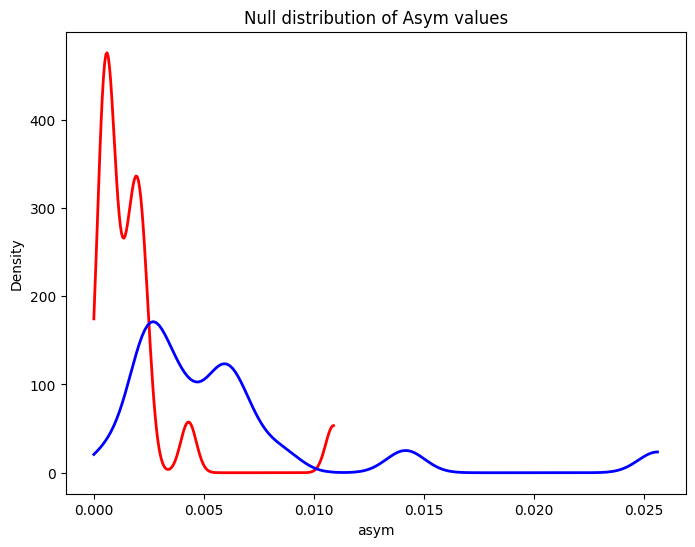

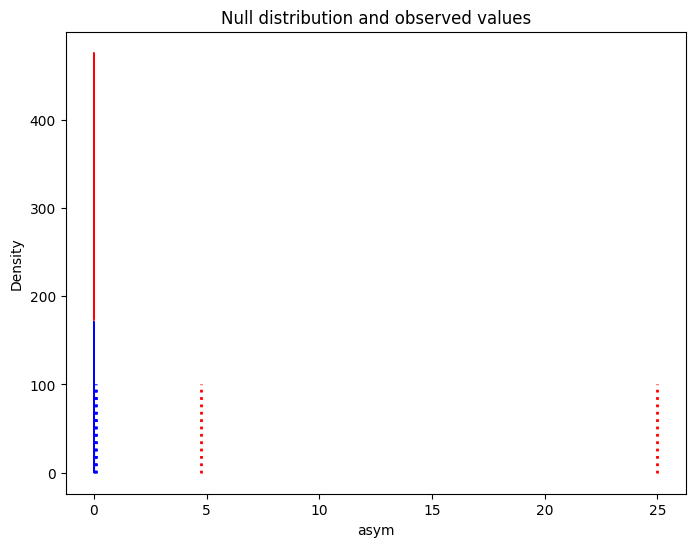

In [ ]:
# @title Null distribution for arrow-of-time asymmetry {"vertical-output":true,"display-mode":"form"}


import numpy as np
import scipy.io
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
from google.colab import drive
import matplotlib.pyplot as plt

def load_mat_from_drive(file_path):
    """
    Load a .mat file from Google Drive in Google Colab.

    Parameters:
    file_path : str, path to the .mat file in Google Drive (e.g., '/content/drive/My Drive/Colab Data/data.mat')

    Returns:
    mat_data : dict, contents of the .mat file
    """
    try:
        # Load the .mat file
        mat_data = scipy.io.loadmat(file_path)
        return mat_data
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}. Check the path and ensure the file exists.")
        return None
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None

def ShuffleDistribution( sA, sB, Nshift, Nshuffle ):

    Ntime = len( sA )

    Afr_s = np.zeros((Nshuffle, 1))

    for s in range(Nshuffle):

        shift = np.random.randint(2*Nshift, 4*Nshift)

        sS = np.roll(sB, -shift, axis=0)

        (ishift, cc_i, Afr_s[s]) = InsideoutCorrelation( sA, sS, Nshift )

        if np.mod(s,1000) == 0:
            print(s)

    return Afr_s


def InsideoutCorrelation( sA, sB, Nshift):

    ishift = np.arange(-Nshift, Nshift + 1)

    cc_i = np.zeros((Nshift * 2 + 1, 1))

    # Compute lagged correlation
    for i, shift in enumerate(ishift):
        # Positive shift correlates earlier values
        sS = np.roll(sB, -shift, axis=0)

        # Compute correlation
        cc_i[i] = np.corrcoef( sA.T, sS.T)[0,1]

    # Signed mutual information approximation
    #IM_i = -0.5 * np.sign(cc_i) * np.log(1 - cc_i ** 2)

    # Mutual information approximation
    IM_i = -0.5 * np.log(1 - cc_i ** 2)


    # Forward-reverse asymmetry
    ixpos = np.where(ishift > 0)[0]
    ixneg = np.where(ishift < 0)[0][::-1]

    fowrev_i = 100 * (IM_i[ixpos] - IM_i[ixneg]) ** 2

    # Replace infinities with 0
    fowrev_i[np.isinf(fowrev_i)] = 0

    # Average over shifts and scale
    fowrev = np.nansum(fowrev_i, axis=0)

    return ishift, cc_i, fowrev

def compute_fourier_spectrum(signal, min_period=2, max_period=120):
    """
    Compute the Fourier spectrum of a discretely sampled signal for periods between min_period and max_period.

    Parameters:
    signal : array-like, input signal
    min_period : float, minimum period in samples (default: 2)
    max_period : float, maximum period in samples (default: 40)

    Returns:
    periods : array, periods in samples
    power : array, power spectrum
    """
    # Convert signal to numpy array
    signal = np.array(signal)
    signal = np.squeeze(signal)
    N = len(signal)

    # Define frequency range (inverse of periods)
    freqs = 1.0 / np.linspace(min_period, max_period, 1000)

    # Initialize power spectrum
    power = np.zeros(len(freqs))

    # Compute Fourier transform for each frequency
    for i, freq in enumerate(freqs):
        # Create complex exponential for this frequency
        t = np.arange(N)
        kernel = np.exp(-2j * np.pi * freq * t)

        # Compute power (square of absolute value of dot product)
        power[i] = np.abs(np.dot(signal, kernel))**2 / N

    # Convert frequencies back to periods
    periods = 1.0 / freqs

    return periods, power

# Example usage
if __name__ == "__main__":
    # Mount Google Drive
    drive.mount('/content/drive')

    # Specify the path to your .mat file
    file_path = '/content/drive/My Drive/Advanced Statistics/Data files/LaggedCorrelationMRIData.mat'  # Update with your file path

    # Load the .mat file
    mat_data = load_mat_from_drive(file_path)

    if mat_data is not None:
        # Display the keys in the .mat file
        print("Variables in .mat file:", mat_data.keys())

        # Access variables
        ishift    = mat_data['ishift']
        cc_top1_i = mat_data['cc_top1_i']
        cc_top2_i = mat_data['cc_top2_i']
        cc_med1_i = mat_data['cc_med1_i']
        cc_med2_i = mat_data['cc_med2_i']
        TopA1     = mat_data['TopA1']
        TopA2     = mat_data['TopA2']
        MedA1     = mat_data['MedA1']
        MedA2     = mat_data['MedA2']
        TopB1     = mat_data['TopB1']
        TopB2     = mat_data['TopB2']
        MedB1     = mat_data['MedB1']
        MedB2     = mat_data['MedB2']

        Nshift    = np.max(ishift)

        (ishift, cc_top1_i, Afr_top1) = InsideoutCorrelation( TopA1, TopB1, Nshift)
        (ishift, cc_top2_i, Afr_top2) = InsideoutCorrelation( TopA2, TopB2, Nshift)

        (ishift, cc_med1_i, Afr_med1) = InsideoutCorrelation( MedA1, MedB1, Nshift)
        (ishift, cc_med2_i, Afr_med2) = InsideoutCorrelation( MedA2, MedB2, Nshift)

        print( "Observed asymmetry values:", Afr_top1, Afr_top2, Afr_med1, Afr_med2 )

        Bins = np.linspace(0, 0.1, 100)

        shuffleflag = True

        if shuffleflag:

            Nshuffle = 10000

            Afr_top_s = ShuffleDistribution(TopA1, TopB1, Nshift, Nshuffle )
            Afr_med_s = ShuffleDistribution(MedA2, MedB2, Nshift, Nshuffle )

            Afr_top_s = np.squeeze(Afr_top_s)
            Afr_med_s = np.squeeze(Afr_med_s)

            # Plot smoothed historgrams of distribution
            kde_top = gaussian_kde(Afr_top_s)
            kde_med = gaussian_kde(Afr_med_s)

            x_top = np.linspace(0, np.max(Afr_top_s), 200)
            x_med = np.linspace(0, np.max(Afr_med_s), 200)

            kde_values_top = kde_top(x_top)
            kde_values_med = kde_med(x_med)



            Nbin = 40

            plt.figure(figsize=(8, 6))
            plt.plot( x_top, kde_values_top, color='red', linewidth=2, label='Null Top' )
            plt.plot( x_med, kde_values_med, color='blue', linewidth=2, label='Null Med' )
            #plt.plot( [Afr_top1, Afr_top1], [0,2], 'r', linewidth=2, label='Top1' )
            #plt.plot( [Afr_top2, Afr_top2], [0,2], 'r', linewidth=2, label='Top2' )
            #plt.plot( [Afr_med1, Afr_med1], [0,2], 'r', linewidth=2, label='Med1' )
            #plt.plot( [Afr_med2, Afr_med2], [0,2], 'b', linewidth=2, label='Med2' )
            plt.title("Null distribution of Asym values")
            plt.xlabel('asym')
            plt.ylabel('Density')


            plt.figure(figsize=(8, 6))
            plt.plot( x_top, kde_values_top, color='red', linewidth=1, label='Null Top' )
            plt.plot( x_med, kde_values_med, color='blue', linewidth=1, label='Null Med' )
            plt.plot( [Afr_top1, Afr_top1], [0,100], 'r:', linewidth=2, label='Top1' )
            plt.plot( [Afr_top2, Afr_top2], [0,100], 'r:', linewidth=2, label='Top2' )
            plt.plot( [Afr_med1, Afr_med1], [0,100], 'b:', linewidth=2, label='Med1' )
            plt.plot( [Afr_med2, Afr_med2], [0,100], 'b:', linewidth=2, label='Med2' )
            plt.title("Null distribution and observed values")
            plt.xlabel('asym')
            plt.ylabel('Density')






Mounted at /content/drive
Variables in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'Nshift', 'iShift', 'Nj', 'E_lj', 'R_lj'])
0
100
200
300
400
500
600
700
800
900


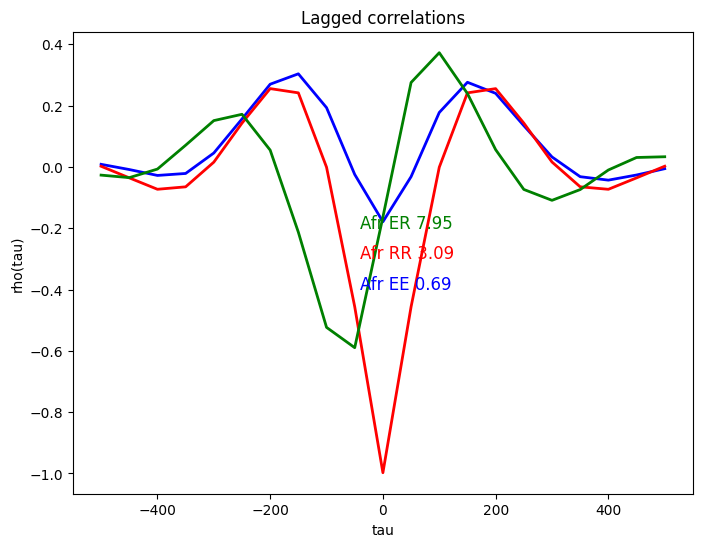

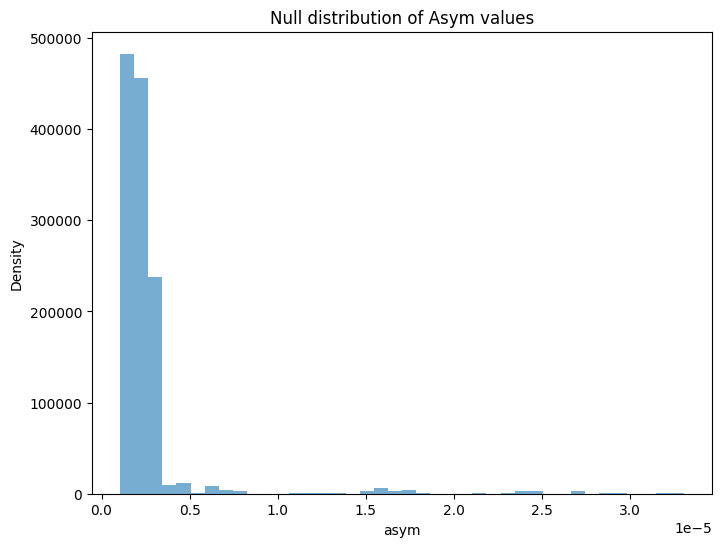

In [ ]:
# @title Arrow-of-time asymmetry, dynamic systems example {"vertical-output":true,"display-mode":"form"}


import numpy as np
import scipy.io
from scipy.stats import pearsonr
from google.colab import drive
import matplotlib.pyplot as plt

def load_mat_from_drive(file_path):
    """
    Load a .mat file from Google Drive in Google Colab.

    Parameters:
    file_path : str, path to the .mat file in Google Drive (e.g., '/content/drive/My Drive/Colab Data/data.mat')

    Returns:
    mat_data : dict, contents of the .mat file
    """
    try:
        # Load the .mat file
        mat_data = scipy.io.loadmat(file_path)
        return mat_data
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}. Check the path and ensure the file exists.")
        return None
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None

def ShuffleDistribution( sA, sB, ishift, Nshuffle ):

    Nsignal = len( sA )

    Nshift = np.max(ishift)
    Nshift = Nshift.astype(int)

    Afr_s = np.zeros((Nshuffle, 1))

    for s in range(Nshuffle):

        ranshift = np.random.randint(2*Nshift, 4*Nshift)

        sS = np.roll(sB, -ranshift, axis=0)

        (cc_i, Afr_s[s]) = InsideoutCorrelation( sA, sS, ishift )

        if np.mod(s, 100) == 0:
            print( s )

    return Afr_s


def InsideoutCorrelation( sA, sB, ishift):

    cc_i = np.zeros((len(ishift), ))

    # Compute lagged correlation
    for i, shift in enumerate(ishift):
        # Positive shift correlates earlier values
        sS = np.roll(sB, -shift, axis=0)

        # Compute correlation
        cc_i[i] = np.corrcoef( sA.T, sS.T)[0,1]

    # Signed mutual information approximation
    # IM_i = -0.5 * np.sign(cc_i) * np.log(1 - cc_i ** 2)

    # Mutual information approximation
    IM_i = -0.5 * np.log(1 - cc_i ** 2)


    # Forward-reverse asymmetry
    ixpos = np.where(ishift > 0)[0]
    ixneg = np.where(ishift < 0)[0]

    fowrev_i = 100 * (IM_i[ixpos] - IM_i[ixneg]) ** 2

    # Replace infinities with 0
    fowrev_i[np.isinf(fowrev_i)] = 0

    # Integral area over shifts and scale
    Afr= np.nansum(fowrev_i, axis=0)

    return cc_i, Afr

# Example usage
if __name__ == "__main__":
    # Mount Google Drive
    drive.mount('/content/drive')

    # Specify the path to your .mat file
    file_path = '/content/drive/My Drive/Advanced Statistics/Data files/LaggedCorrelationNESSData.mat'  # Update with your file path

    # Load the .mat file
    mat_data = load_mat_from_drive(file_path)

    if mat_data is not None:
        # Display the keys in the .mat file
        print("Variables in .mat file:", mat_data.keys())

        # Access variables
        Nshift  = mat_data['Nshift']
        iShift  = mat_data['iShift']
        Nj      = mat_data['Nj']
        E_lj    = mat_data['E_lj']
        R_lj    = mat_data['R_lj']

        # extract signal time-courses of interest
        E0_j = np.squeeze(E_lj[0, :])
        E1_j = np.squeeze(E_lj[1, :])

        R0_j = np.squeeze(R_lj[0, :])
        R1_j = np.squeeze(R_lj[1, :])

        DE_j = np.squeeze(E_lj[0, :] - E_lj[1, :])
        DR_j = np.squeeze(R_lj[0, :] - R_lj[1, :])

        # subsample the signal for speed
        E0_j = E0_j[::10]
        E1_j = E1_j[::10]

        R0_j = R0_j[::10]
        R1_j = R1_j[::10]

        DE_j = DE_j[::10]
        DR_j = DR_j[::10]

        # variables were read in a weird type (unsigned int?)
        Nshift = np.squeeze( Nshift / 10 )
        Nshift = Nshift.astype(int)

        # Choose coarser sampling of shift tau (weird stuffgoint in which types)
        ishift    = np.linspace(0, 2*Nshift, 21, endpoint=True ) - Nshift
        ishift    = ishift.astype(int)

        # compute asymmetry areas, fow-rev
        (cc_EE_i, Afr_EE) = InsideoutCorrelation( E0_j, E1_j, ishift)
        (cc_RR_i, Afr_RR) = InsideoutCorrelation( R0_j, R1_j, ishift)
        (cc_ER_i, Afr_ER) = InsideoutCorrelation( DE_j, DR_j, ishift)

        plt.figure(figsize=(8, 6))
        plt.plot( ishift, cc_EE_i, 'b', linewidth=2, label='EE' )
        plt.plot( ishift, cc_RR_i, 'r', linewidth=2, label='RR' )
        plt.plot( ishift, cc_ER_i, 'g', linewidth=2, label='ER' )
        plt.text( -40, -0.4, f'Afr EE {Afr_EE:.2f}', fontsize=12, color='b' )
        plt.text( -40, -0.3, f'Afr RR {Afr_RR:.2f}', fontsize=12, color='r' )
        plt.text( -40, -0.2, f'Afr ER {Afr_ER:.2f}', fontsize=12, color='g' )
        plt.title("Lagged correlations")
        plt.xlabel('tau')
        plt.ylabel('rho(tau)')

        shuffleflag = True

        if shuffleflag:

            Nshuffle = 1000

            Afr_s = ShuffleDistribution(DE_j, DR_j, ishift, Nshuffle )

            # Plot histogram of shuffle distribution
            Nbin = 40

            plt.figure(figsize=(8, 6))
            plt.hist(Afr_s, bins=Nbin, density=True, alpha=0.6 )
            plt.title("Null distribution of Asym values")
            plt.xlabel('asym')
            plt.ylabel('Density')







# **6. Null distributions for entropy**

<br>

When computing measures of disorder or entropy, the shuffling approach faces some difficulties, because randomization typically inflates disorder or entropy.

<br>

To illustrate the problem, I use our recently published study on changes of entropy production in resting-state EEG signals measured from adolescent females.

<br>

The recordings were performed by our colleagues in Budapest and the analysis was developed and carried out in Magdeburg.

<br>

[Szakacs, Mutlu, et al. 2024](https://advanced.onlinelibrary.wiley.com/doi/10.1002/advs.202308364)

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_adolescent_age_and_maturity.png" width="600">



# Entropy production by trajectory of EEG macrostates

We recorded high-density EEG from resting subjects, established whole-scalp phase coherence patterns at 100 Hz, and analyzed the development of such patterns over time. Even though these coherence patterns develop in a temporally continuous manner, the dynamics of whole-scalp coherence can be approximated in terms of a sequence of distinct macrostates. The level of detail in this description depends on the chosen number of categorical states.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_trajectory_sequence.png" width="800">


<br>

Panel a shows a representative trajectory of 128-dimensional microstates, projected into 3 dimensions. Sequence duration is 10 s (or 1000 microstates). Note that the trajectory moves largely continuously (in 10 ms steps). The apparent jumps (straight dotted lines) are computational artefacts owed to the ambiguity of eigenvector signs.

Panel b illustrates the same sequence in terms of categorical macrostates distinguished by color.



# Macrostate transitions

Having defined distinct "macrostates" (as categories or clusters of "microstates"), we established the statistics of macrostate 'transitions' for every recorded sequence of eigenvectors.  Consider an observed sequence of $N$ eigenvectors assigned to $K$ distinct clusters. For simplicity, we made sequences cyclical by pretending that the first vector succeeded the last vector. From every such sequence, we established transition counts $n^j_k$, that is, the observed number of transitions from cluster of origin $j$ to cluster of destination $k\neq j$.  

$$
n^j_k \quad \mathit{from} \,\, j \,\, \mathit{to} \,\,k, \qquad\qquad N_\mathit{trans} \equiv \sum_{k=1}^K \sum_{j\neq k} n^j_k
$$

where $N_\mathit{trans}$ is the total number of transitions . As any transition is *from* one state *to* another state, row and column sums in the matrices $n^j_k$ are equal

$$
\sum_k n^j_k = \sum_k n^k_j, \qquad\qquad \forall j
$$

<br>

Below is an example of an observed transition matrix. Note that this matrix is not exactly symmetric. This asymmetry could be accidental (due to the finite duration of the observed sequence) or it could be systematic (due to non-equilibrium dynamics of brain activity).

<br>

**We want to determine whether the observed degree of asymmetry is statistically significant!**

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/TransitionMatrixAsymmetric.png" width="400">

<br>



# Entropy production

The commonly used expression for entropy production in non-equilibrium systems [(Schnakenberg, 1976)](https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.48.571) is the weighted sum of imbalanced flows


$$
\dot S_\mathit{tot} = \sum_{k\neq j} \left[ w^j_k P_j - w^k_j P_k \right] \log\frac{w^j_k P_j}{w^k_j P_k}
$$

where the sum is taken over all *unordered* pairs $k\neq j$.

Each unordered pair $k\neq j$ contributes

$$
\dot S_{jk} = \dot S_{kj} = \frac{n^j_k - n^k_j}{N} \log\frac{n^j_k}{n^k_j}
$$

to the total entropy production.

<br>

When no transitions were observed for a subset of ordered pairs $k\to j$, the associated transition flows vanish and the entropy production can be arbitrarily large. To avoid this issue, we changed the value of all $n^k_j=0$ to $n^k_j=1$. This arbitrary choice lowered entropy production and set the numerical scale for its absolute value. Due to this arbitrary modification, only the relative values of entropy production are meaningful and interpretable.



In [ ]:
# @title Bootstrapping entropy-production, the wrong way {"vertical-output":true,"display-mode":"form"}

import numpy as np
from ipywidgets import interact
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d
from scipy.special import gamma, beta, hyp2f1

def TransitionMatrix():

    Tjk = np.array([
         [0, 1, 5, 29, 1, 1, 7, 35, 74, 28, 3, 30],
         [3, 0, 0, 4, 24, 48, 17, 3, 1, 9, 60, 2],
         [5, 0, 0, 19, 51, 0, 20, 0, 40, 4, 17, 2],
         [30, 2, 16, 0, 0, 1, 14, 56, 36, 25, 1, 16],
         [2, 22, 45, 2, 0, 70, 0, 0, 3, 7, 43, 22],
         [2, 46, 3, 2, 79, 0, 14, 78, 0, 1, 3, 57],
         [10, 19, 14, 12, 2, 19, 0, 23, 1, 6, 1, 1],
         [29, 2, 0, 47, 0, 86, 29, 0, 0, 1, 1, 43],
         [78, 0, 48, 34, 2, 0, 0, 1, 0, 22, 95, 0],
         [22, 10, 3, 32, 1, 0, 6, 2, 41, 0, 37, 41],
         [1, 66, 19, 2, 42, 5, 0, 0, 84, 42, 0, 0],
         [32, 3, 5, 14, 14, 55, 1, 40, 0, 50, 0, 0]
    ])

    return Tjk

def GetEntropyValue(Tij):
    """
    Compute an entropy-like value from a transition count matrix Tij.

    Parameters:
    Tij : 2D NumPy array, transition count matrix

    Returns:
    hval : float, computed entropy value
    """
    # Validate input
    if not isinstance(Tij, np.ndarray) or Tij.ndim != 2:
        raise ValueError("Tij must be a 2D NumPy array.")

    # Add 1 to Tij to avoid division by zero
    Pij = Tij + 1

    # Normalize to form probability matrix
    Pij = Pij / np.sum(Pij)

    # Compute Pij' (transpose of Pij)
    Pij_transpose = Pij.T

    # Compute element-wise term: Pij .* log(Pij ./ Pij')
    ratio = Pij / Pij_transpose
    Hij = Pij * np.log(ratio)

    # Sum all elements
    Hval = np.sum(Hij)

    return Hval

def GetTransitionCounts(Ncluster, sequence):
    """
    Compute transition count matrix from a state sequence.

    Parameters:
    Ncluster : int, number of states
    sequence : array-like, sequence of state indices (1-based)

    Returns:
    Tij : 2D array, transition count matrix
    """
    Tij = np.zeros((Ncluster, Ncluster))
    sequence = np.array(sequence, dtype=int) - 1  # Convert to 0-based
    for i in range(len(sequence) - 1):
        current_state = sequence[i]
        next_state = sequence[i + 1]
        if 0 <= current_state < Ncluster and 0 <= next_state < Ncluster:
            Tij[current_state, next_state] += 1
    return Tij


def BootstrapEntropy(Tij, Nsequence, Nbootstrap):
    """
    Simulate a DTMC and compute bootstrap entropy estimates.

    Parameters:
    Tij : 2D array, transition count matrix (Ncluster x Ncluster)
    Nsequence : int, length of each bootstrap sequence
    Nbootstrap : int, number of bootstrap iterations

    Returns:
    Hbs : array, entropy values for each bootstrap sample
    """
    # Get number of clusters
    Ncluster = Tij.shape[0]

    # Compute transition probabilities Pitoj
    Pitoj = np.zeros((Ncluster, Ncluster))
    row_sums = np.sum(Tij, axis=1, keepdims=True)
    Pitoj = Tij / row_sums;

    # Compute overall state probabilities Pi
    Pi = np.sum(Tij, axis=1) / np.sum(Tij)

    # Initialize bootstrap arrays
    bsID = np.full(Nsequence, np.nan)  # State sequence
    Hbs = np.full(Nbootstrap, np.nan)  # Entropy values

    # Bootstrap iterations
    for k in range(Nbootstrap):
        # Initialize sequence with first state
        bsID[0] = NextID(Pi)

        # Generate sequence
        for j in range(1, Nsequence):
            iid = int(bsID[j-1] - 1)  # Convert to 0-based for Python
            nid = NextID(Pitoj[iid, :])
            bsID[j] = nid

        # Compute transition counts for bootstrap sequence
        bsTij = GetTransitionCounts(Ncluster, bsID)

        # Compute entropy
        Hbs[k] = GetEntropyValue(bsTij)

        # Progress update
        if (k + 1) % 100 == 0:
            print(f"[Bootstrap {k + 1}/{Nbootstrap}]")

    return Hbs

def NextID(Pi):
    """
    Sample a state index based on a probability distribution using inverse transform sampling.

    Parameters:
    Pi : array-like, probability distribution over states (non-negative, sums to ~1)

    Returns:
    iid : int, sampled state index (1-based to match MATLAB)
    """
    # Convert input to numpy array and normalize
    Pi = np.array(Pi, dtype=float)
    if np.any(Pi < 0):
        raise ValueError("Probabilities must be non-negative.")
    if np.sum(Pi) == 0:
        raise ValueError("Probability distribution cannot be all zeros.")
    Pi = Pi / np.sum(Pi)  # Normalize to sum to 1

    # Generate a random number in [0, 1]
    rand_val = np.random.random()

    # Compute cumulative sum of probabilities
    cumsum_Pi = np.cumsum(Pi)

    # Find the first index where rand <= cumsum(Pi)
    idx = rand_val <= cumsum_Pi

    # Find the first True index (equivalent to MATLAB's find(idx==1))
    ix = np.where(idx)[0]

    if len(ix) == 0:
        raise RuntimeError("No valid index found (possible numerical issue).")

    # Take the first index (1-based to match MATLAB)
    iid = ix[0] + 1

    return iid

# Example usage
def plot_observed_and_bootstrapped_entropy( Nbootstrap=500, Nsequence=5000 ):

    # observed transition matrix
    Tij = TransitionMatrix();

    print(f"Observed Sequence length: {Nsequence}")

    # observed entropy value

    Hobs = GetEntropyValue(Tij)

    print(f"Observed Entropy: {Hobs:.4f}")

    Nbootstrap = 500

    # Run bootstrap entropy estimation
    Hbs = BootstrapEntropy(Tij, Nsequence, Nbootstrap)


    # Smoothed histogram of distribution
    kde = gaussian_kde(Hbs)
    h = np.linspace(0, np.max(Hbs), 200)

    kde_values = kde(h)

    # Print summary
    print(f"Mean Entropy: {np.mean(Hbs):.4f}")
    print(f"Std Entropy: {np.std(Hbs, ddof=1):.4f}")

    # Plot histogram of entropy values
    plt.figure(figsize=(8, 6))
    plt.hist(Hbs, bins=50, density=True, alpha=0.6, label='Bootstrapped')
    plt.plot(h, kde_values, 'r:', linewidth=2, label='KDE')
    plt.plot([Hobs,Hobs], [0,np.max(kde_values)], 'r', linewidth=2, label='Observed')
    plt.xlabel('Entropy')
    plt.ylabel('Density')
    plt.title('Observed and Bootstrapped Entropy Values')

    plt.legend()

    plt.show()

    return;

interact( plot_observed_and_bootstrapped_entropy, Nsequence = (5000, 50000, 45000), Nbootstrap = (500, 5000, 500) )



interactive(children=(IntSlider(value=500, description='Nbootstrap', max=5000, min=500, step=500), IntSlider(v…

<function __main__.plot_observed_and_bootstrapped_entropy(Nbootstrap=500, Nsequence=5000)>

# Bootstrapping entropy the right way

We find that bootstrapped entropy values are distributed **to the right** of our observed value. This is a suprise, as we would expect bootstrapped values to distribute on both sides (**left and right**) of the observed value.

<br>

The problem stems from the finite length of the observed trajectory. As we generate very long synthetic trajectories, the entropy value approaches the observed value, demonstrating that our bootstrapping procedure works.

<br>

Evidently, generating trajectories of finite length introduces noise, which contributes spurious entropy and inflates the bootstrapped values. How much noise does a trajectory of a certain length contribute?

<br>

We can answer this empirically, by generating trajectories from a symmetric matrix, for which the theoretical entropy production is exactly zero. Accordingly, any entropy production that we observe for a symmetric matrix must be due to noise.

<br>

The average amount of spuriously produced entropy can then be used to correct (left-shift) our boostrapped distributions.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/TransitionMatrixAsymmetric.png" width="400">
$\qquad\qquad$
<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/TransitionMatrixSymmetric.png" width="400">

<br>

**In this way, we can establish the statistical significance of our observed entropy value.**





In [ ]:
# @title Bootstrapping entropy-production, the right way {"vertical-output":true,"display-mode":"form"}

import numpy as np
from ipywidgets import interact
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d
from scipy.special import gamma, beta, hyp2f1

def TransitionMatrix():

    Tjk = np.array([
         [0, 1, 5, 29, 1, 1, 7, 35, 74, 28, 3, 30],
         [3, 0, 0, 4, 24, 48, 17, 3, 1, 9, 60, 2],
         [5, 0, 0, 19, 51, 0, 20, 0, 40, 4, 17, 2],
         [30, 2, 16, 0, 0, 1, 14, 56, 36, 25, 1, 16],
         [2, 22, 45, 2, 0, 70, 0, 0, 3, 7, 43, 22],
         [2, 46, 3, 2, 79, 0, 14, 78, 0, 1, 3, 57],
         [10, 19, 14, 12, 2, 19, 0, 23, 1, 6, 1, 1],
         [29, 2, 0, 47, 0, 86, 29, 0, 0, 1, 1, 43],
         [78, 0, 48, 34, 2, 0, 0, 1, 0, 22, 95, 0],
         [22, 10, 3, 32, 1, 0, 6, 2, 41, 0, 37, 41],
         [1, 66, 19, 2, 42, 5, 0, 0, 84, 42, 0, 0],
         [32, 3, 5, 14, 14, 55, 1, 40, 0, 50, 0, 0]
    ])

    return Tjk

def GetEntropyValue(Tij):
    """
    Compute an entropy-like value from a transition count matrix Tij.

    Parameters:
    Tij : 2D NumPy array, transition count matrix

    Returns:
    hval : float, computed entropy value
    """
    # Validate input
    if not isinstance(Tij, np.ndarray) or Tij.ndim != 2:
        raise ValueError("Tij must be a 2D NumPy array.")

    # Add 1 to Tij to avoid division by zero
    Pij = Tij + 1

    # Normalize to form probability matrix
    Pij = Pij / np.sum(Pij)

    # Compute Pij' (transpose of Pij)
    Pij_transpose = Pij.T

    # Compute element-wise term: Pij .* log(Pij ./ Pij')
    ratio = Pij / Pij_transpose
    Hij = Pij * np.log(ratio)

    # Sum all elements
    Hval = np.sum(Hij)

    return Hval

def GetTransitionCounts(Ncluster, sequence):
    """
    Compute transition count matrix from a state sequence.

    Parameters:
    Ncluster : int, number of states
    sequence : array-like, sequence of state indices (1-based)

    Returns:
    Tij : 2D array, transition count matrix
    """
    Tij = np.zeros((Ncluster, Ncluster))
    sequence = np.array(sequence, dtype=int) - 1  # Convert to 0-based
    for i in range(len(sequence) - 1):
        current_state = sequence[i]
        next_state = sequence[i + 1]
        if 0 <= current_state < Ncluster and 0 <= next_state < Ncluster:
            Tij[current_state, next_state] += 1
    return Tij


def BootstrapEntropy(Tij, Nsequence, Nbootstrap):
    """
    Simulate a DTMC and compute bootstrap entropy estimates.

    Parameters:
    Tij : 2D array, transition count matrix (Ncluster x Ncluster)
    Nsequence : int, length of each bootstrap sequence
    Nbootstrap : int, number of bootstrap iterations

    Returns:
    Hbs : array, entropy values for each bootstrap sample
    """
    # Get number of clusters
    Ncluster = Tij.shape[0]

    # Compute transition probabilities Pitoj
    Pitoj = np.zeros((Ncluster, Ncluster))
    row_sums = np.sum(Tij, axis=1, keepdims=True)
    Pitoj = Tij / row_sums;

    # Compute overall state probabilities Pi
    Pi = np.sum(Tij, axis=1) / np.sum(Tij)

    # Initialize bootstrap arrays
    bsID = np.full(Nsequence, np.nan)  # State sequence
    Hbs = np.full(Nbootstrap, np.nan)  # Entropy values

    # Bootstrap iterations
    for k in range(Nbootstrap):
        # Initialize sequence with first state
        bsID[0] = NextID(Pi)

        # Generate sequence
        for j in range(1, Nsequence):
            iid = int(bsID[j-1] - 1)  # Convert to 0-based for Python
            nid = NextID(Pitoj[iid, :])
            bsID[j] = nid

        # Compute transition counts for bootstrap sequence
        bsTij = GetTransitionCounts(Ncluster, bsID)

        # Compute entropy
        Hbs[k] = GetEntropyValue(bsTij)

        # Progress update
        if (k + 1) % 100 == 0:
            print(f"[Bootstrap {k + 1}/{Nbootstrap}]")

    return Hbs

def NextID(Pi):
    """
    Sample a state index based on a probability distribution using inverse transform sampling.

    Parameters:
    Pi : array-like, probability distribution over states (non-negative, sums to ~1)

    Returns:
    iid : int, sampled state index (1-based to match MATLAB)
    """
    # Convert input to numpy array and normalize
    Pi = np.array(Pi, dtype=float)
    if np.any(Pi < 0):
        raise ValueError("Probabilities must be non-negative.")
    if np.sum(Pi) == 0:
        raise ValueError("Probability distribution cannot be all zeros.")
    Pi = Pi / np.sum(Pi)  # Normalize to sum to 1

    # Generate a random number in [0, 1]
    rand_val = np.random.random()

    # Compute cumulative sum of probabilities
    cumsum_Pi = np.cumsum(Pi)

    # Find the first index where rand <= cumsum(Pi)
    idx = rand_val <= cumsum_Pi

    # Find the first True index (equivalent to MATLAB's find(idx==1))
    ix = np.where(idx)[0]

    if len(ix) == 0:
        raise RuntimeError("No valid index found (possible numerical issue).")

    # Take the first index (1-based to match MATLAB)
    iid = ix[0] + 1

    return iid

# Example usage
def plot_observed_and_corrected_bootstrap( Nbootstrap=500 ):

    # observed transition matrix
    Tij_asym = TransitionMatrix();

    Nsequence = np.sum(Tij_asym)

    print(f"Observed Sequence length: {Nsequence}")

    # observed entropy value

    Hobs = GetEntropyValue(Tij_asym)

    print(f"Observed Entropy: {Hobs:.4f}")

    # Run bootstrap entropy estimation
    Hbs_asym = BootstrapEntropy(Tij_asym, Nsequence, Nbootstrap)

    # Symmetric transition matrix
    Tij_sym = ( Tij_asym + Tij_asym.T ) / 2;

    Hbs_sym = BootstrapEntropy(Tij_sym, Nsequence, Nbootstrap)

    # Smoothed histogram of asymmetric distribution
    kde_asym = gaussian_kde(Hbs_asym)
    h_asym = np.linspace(0, np.max(Hbs_asym), 200)
    kde_asym_values = kde_asym(h_asym)

    # Smoothes histogram of symmetric distribution
    kde_sym = gaussian_kde(Hbs_sym)
    h_sym = np.linspace(0, np.max(Hbs_sym), 200)
    kde_sym_values = kde_sym(h_sym)

    # Left-shift for correction
    h_shift = np.mean(Hbs_sym)
    h_corr_asym = h_asym - h_shift
    h_corr_sym = h_sym - h_shift

    # Print summary
    print(f"Mean Entropy: {np.mean(Hbs_asym):.4f}")
    print(f"Std Entropy: {np.std(Hbs_asym, ddof=1):.4f}")

    # Plot histogram of entropy values
    plt.figure(figsize=(8, 6))
    plt.plot(h_corr_sym, kde_sym_values, 'k:', linewidth=2, label='Symmmetric')
    plt.plot(h_corr_asym, kde_asym_values, 'r:', linewidth=2, label='Asymmetric')
    plt.plot([Hobs,Hobs], [0,np.max(kde_sym_values)], 'r', linewidth=2, label='Observed')
    plt.xlabel('Entropy')
    plt.ylabel('Density')
    plt.title('Observed and Bootstrapped Entropy Values')

    plt.legend()

    plt.show()

    return;

interact( plot_observed_and_corrected_bootstrap, Nbootstrap = (500, 5000, 500) )



interactive(children=(IntSlider(value=500, description='Nbootstrap', max=5000, min=500, step=500), Output()), …

<function __main__.plot_observed_and_corrected_bootstrap(Nbootstrap=500)>

# **Summary**

This figure summarizes the corrections that are required for bootstrapping entropy production.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_entropy_production.png" width="800">

<br>

# **Summary**

**1. Bayes Factor**

**2. Bayesian Information Criterion (BIC)**

**3. False discovery corrections**

**4. Bootstrapping for standard error and confidence**

**5. Shuffling for null distributions**

<br>

# **Following lectures**

**Lecture 7: Bootstrapping examples (Stepan Aleshin)**

**Lecture 8: GLM examples (Stepan Aleshin)**

**Lecture 9: Linear discriminant analysis (Jochen Braun)**

**Lecture 10: Multivariate LDA (Jochen Braun)**